# Импорты библиотек

In [198]:
!pip install scipy


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [199]:
!pip install scikit_posthocs


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [200]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np
from matplotlib.ticker import MaxNLocator
from IPython.display import display
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests
from IPython.display import Markdown, display
import scikit_posthocs as sp
import seaborn as sns
import itertools


# Чтение данных

In [201]:
# Для отображения чисел не в экспоненциальном виде, а обрезанными до двух знаков после запятой
pd.options.display.float_format = '{:.2f}'.format

In [202]:
df_path = "../data/marketplace.csv"

df = pd.read_csv(df_path)

In [203]:
#Приведение дат к datetime
date_cols = ["first_login", "reg_dt", "first_buy"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25335 entries, 0 to 25334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       25335 non-null  object        
 1   platform_num  25335 non-null  int64         
 2   first_login   25335 non-null  datetime64[ns]
 3   reg_dt        25331 non-null  datetime64[ns]
 4   browser       25335 non-null  object        
 5   first_buy     24361 non-null  datetime64[ns]
 6   target        25335 non-null  float64       
 7   total_buy     25335 non-null  float64       
 8   total_return  25335 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(1), object(2)
memory usage: 1.7+ MB


# Чистка и подготовка данных

**Обнаружение дублей по пользователям**

На этапе проверки качества данных был проведён анализ уникальности идентификаторов пользователей (user_id).
Всего в датасете содержится 25 335 строк и 25 331 уникальный user_id, то есть 4 пользователя представлены двумя строками каждый.
Доля таких пользователей от всей клиентской базы составляет около 0,016 %, доля «лишних» строк — также порядка 0,016 %.
Формально влияние дублей на агрегированные показатели невелико, однако для корректного анализа на уровне пользователя важно, чтобы каждому user_id соответствовала ровно одна запись.

Поэтому было принято решение привести датасет к формату «одна строка = один пользователь».

**Алгоритм устранения дублей**

Так как данные представляют собой снимок состояния пользователей на определённые даты, для каждого user_id мы оставляем наиболее «свежий» срез. В качестве приближения к времени среза используем дату первого входа в личный кабинет (first_login):

1. Сортируем датафрейм по user_id и first_login по возрастанию.
В результате для каждого пользователя строки упорядочены от более ранних логинов к более поздним.

2. Удаляем дубликаты user_id, оставляя последнюю строку для каждого пользователя (keep="last"), то есть запись с максимально поздним first_login.

3. Сбрасываем индекс и дополнительно проверяем, что user_id стал уникален.

Таким образом, мы получаем очищенный датасет, в котором каждая строка соответствует одному пользователю в его последнем доступном состоянии.

In [204]:
#Устраняю дубликаты user_id, оставляя последнюю строку для каждого пользователя (keep="last"), то есть запись с максимально поздним first_login.
rows_before = df.shape[0]

df_sorted = df.sort_values(["user_id", "first_login"])

df_clean = (
    df_sorted
    .drop_duplicates(subset="user_id", keep="last")
    .reset_index(drop=True)
)

df = df_clean.copy()
rows_after = df.shape[0]

print(f"Строк до очистки:                     {rows_before}")
print(f"Строк после очистки:                  {rows_after}")
print(f"Удалено строк:                        {rows_before - rows_after}")
print(f"user_id уникальны после очистки:      {df_clean['user_id'].is_unique}")

Строк до очистки:                     25335
Строк после очистки:                  25331
Удалено строк:                        4
user_id уникальны после очистки:      True


## Обогащение данных

>
>В пунктах 1-6 мы:
>
>1. Стандартизируем исторические признаки и разбиваем их на корзины (buckets):
>   - исторический коэффициент возвратов (`total_return / total_buy`);
>   - количество устройств (`platform_num`);
>   - «возраст» клиента по дате первой покупки;
>   - лаг между регистрацией и первой покупкой;
>   - объём покупок (`total_buy`);
>   - 2D-признак: крупные клиенты с высокой исторической возвратностью.
>
>2. На основе этих корзин определяем бинарные риск-флаги:
>   - `risk_hist`      — риск по исторической возвратности;
>   - `risk_devices`   — риск по количеству устройств;
>   - `risk_age`       — крайние когорты по «возрасту» клиента;
>   - `risk_lag`       — аномальный или очень большой лаг до первой покупки;
>   - `risk_buy`       — крупные клиенты по обороту;
>   - `risk_2d`        — пересечение «крупный клиент» × «высокая историческая возвратность».
>
>3. Собираем `risk_score` как сумму сработавших флагов.
>
>Важно: все пороги и флаги определяются **только по историческим признакам**, без использования `target`. Target будет нужен только на следующем шаге — для статистической проверки, что у этих риск-клиентов действительно хуже прибыльность.
>

>В пункте 7 мы обогащаем данные несмещенным значением target, а также группирующим флагом, связанным с этим параметром

### 1. Исторический коэффициент возвратов и риск-признак `risk_hist`

**Цель.** Зафиксировать историческое поведение пользователя по возвратам до момента среза.

**Логика**:

1. Рассчитываем исторический коэффициент возвратов:

$$
hist\_return\_rate = \frac{total\_return}{total\_buy}
$$


   только для пользователей, у которых **и покупки, и возвраты > 0**.

2. Выделяем специальные случаи:
   - `нет покупок` — `total_buy = 0` и `total_return = 0`;
   - `только возвраты` — `total_buy = 0`, `total_return > 0`;
   - `0% возвратов` — `total_buy > 0`, `total_return = 0`.

3. Для пользователей с покупками и возвратами (`total_buy > 0` и `total_return > 0`) делим `hist_return_rate` на корзины по фиксированной сетке:

   - `0–10%`
   - `10–50%`
   - `50–100%`
   - `100–500%`
   - `>500%`

   Итого получаем общекомандный набор бакетов:

   - `нет покупок`
   - `только возвраты`
   - `0% возвратов`
   - `0–10%`
   - `10–50%`
   - `50–100%`
   - `100–500%`
   - `>500%`

**Риск-логика (без target).**

   С точки зрения продукта, пользователи с **существенной исторической долей возвратов** потенциально риск-клиенты. Мы считаем риск-зоной:

   - корзину `только возвраты`;
   - все корзины с долей возвратов ≥ 10%:
     - `10–50%`, `50–100%`, `100–500%`, `>500%`.

   На базе этого вводим бинарный признак:

   - `risk_hist = 1`, если пользователь в одной из этих исторических корзин;
   - `risk_hist = 0` — иначе.


In [205]:
# Специальные маски по покупкам/возвратам
mask_no_buys      = (df["total_buy"] == 0) & (df["total_return"] == 0)
mask_only_returns = (df["total_buy"] == 0) & (df["total_return"] > 0)
mask_zero_returns = (df["total_buy"] > 0) & (df["total_return"] == 0)
mask_pos_both     = (df["total_buy"] > 0) & (df["total_return"] > 0)

# Исторический коэффициент возвратов
df["hist_return_rate"] = np.nan
df.loc[mask_pos_both, "hist_return_rate"] = (
    df.loc[mask_pos_both, "total_return"] / df.loc[mask_pos_both, "total_buy"]
)

# Корзины по исторической возвратности
df["hist_return_bucket"] = None
df.loc[mask_no_buys,      "hist_return_bucket"] = "нет покупок"
df.loc[mask_only_returns, "hist_return_bucket"] = "только возвраты"
df.loc[mask_zero_returns, "hist_return_bucket"] = "0% возвратов"

bins_hr   = [0, 0.1, 0.5, 1, 5, np.inf]
labels_hr = ["0–10%", "10–50%", "50–100%", "100–500%", ">500%"]

df.loc[mask_pos_both, "hist_return_bucket"] = pd.cut(
    df.loc[mask_pos_both, "hist_return_rate"],
    bins=bins_hr,
    labels=labels_hr,
    include_lowest=True
)

# Риск-признак по исторической возвратности (без использования target)
hist_risk_buckets = [
    "только возвраты",
    "10–50%", "50–100%", "100–500%", ">500%"
]
df["risk_hist"] = df["hist_return_bucket"].isin(hist_risk_buckets)

df[["user_id", "hist_return_bucket", "hist_return_rate", "risk_hist"]].head()

,user_id,hist_return_bucket,hist_return_rate,risk_hist
0,user_000000,0% возвратов,NaN,False
1,user_000001,0% возвратов,NaN,False
2,user_000002,100–500%,2.49,True
3,user_000003,0% возвратов,NaN,False
4,user_000004,0% возвратов,NaN,False


### 2. Количество устройств и риск-признак `risk_devices`

**Цель.** Выделить пользователей с аномально большим количеством устройств (подозрение на шэринг аккаунта, мошеннические схемы и т.п.).

### Логика:

1. Сначала смотрим, как в принципе распределяется признак `platform_num` и считаем квантили:
   - медиану (Q50),
   - верхний квартиль (Q75),
   - 95-й перцентиль (Q95).

   Значения этих квартилей будут показаны в следующей ячейке с кодом.

2. На основе расчёта квантилей делим пользователей на бакеты:

   - `≤Q50`      — до медианы (типичный пользователь);
   - `(Q50;Q75]` — медиана–верхний квартиль;
   - `(Q75;Q95]` — верхняя часть распределения;
   - `>Q95`      — верхние 5% по количеству устройств (аномально много устройств).

   В нашем датасете по расчётам получается (см. вывод следующей ячейки):

   - Q50 ≈ 3 устройства,
   - Q75 ≈ 6 устройств,
   - Q95 ≈ 20 устройств,

   поэтому бакеты становятся:

   - `≤3`,
   - `4–6`,
   - `7–20`,
   - `>20`.

**Риск-логика (без target).**

   С точки зрения продукта, риск-клиент по устройствам — это пользователь с **аномально большим числом устройств**, то есть из верхних 5%:

   - `risk_devices = 1`, если `platform_num > Q95` (в нашем случае — корзина `>20`);
   - `risk_devices = 0` во всех остальных случаях.

   Таким образом мы фиксируем именно хвост распределения, не глядя на `target`, а только на историческое поведение по устройствам.

In [206]:
# Квантили по количеству устройств
quantiles_plat = df["platform_num"].quantile([0.50, 0.75, 0.95])
print("Квантили platform_num:")
print(quantiles_plat)

b1 = int(quantiles_plat.loc[0.50])   # медиана (Q50)
b2 = int(quantiles_plat.loc[0.75])   # верхний квартиль (Q75)
b3 = int(quantiles_plat.loc[0.95])   # 95-й перцентиль (Q95)

print(f"\nИспользуемые пороги:")
print(f"Q50 = {b1}, Q75 = {b2}, Q95 = {b3}")

bins_plat = [0, b1, b2, b3, np.inf]
labels_plat = [
    f"≤{b1}",          # до медианы
    f"{b1+1}–{b2}",    # медиана–Q75
    f"{b2+1}–{b3}",    # Q75–Q95
    f">{b3}"           # >Q95
]

df["platform_bucket"] = pd.cut(
    df["platform_num"],
    bins=bins_plat,
    labels=labels_plat,
    include_lowest=True
)

# Риск-признак: верхние 5% по количеству устройств (хвост распределения)
df["risk_devices"] = df["platform_bucket"] == f">{b3}"

display(
    df[["user_id", "platform_num", "platform_bucket", "risk_devices"]]
    .head()
)

Квантили platform_num:
0.50    3.00
0.75    6.00
0.95   20.00
Name: platform_num, dtype: float64

Используемые пороги:
Q50 = 3, Q75 = 6, Q95 = 20


,user_id,platform_num,platform_bucket,risk_devices
0,user_000000,12,7–20,False
1,user_000001,1,≤3,False
2,user_000002,5,4–6,False
3,user_000003,3,≤3,False
4,user_000004,1,≤3,False


### 3. «Возраст» клиента и риск-признак `risk_age`

**Цель.** Разделить клиентов на когорты по дате первой покупки (`first_buy`) и выделить крайние группы как потенциально рискованные.

### Логика:

1. Берём только клиентов с ненулевой `first_buy` и считаем квартильные точки по дате первой покупки:
   - Q25, Q50, Q75 для `first_buy`.
   Значения этих квартилей будут показаны в следующей ячейке с кодом.

2. На основе квартилей делим клиентов на бакеты (когорты по «возрасту»):

   - `Старые клиенты (Q1)`     — первая покупка до Q25;
   - `Ранние клиенты (Q2)`     — между Q25 и Q50 включительно;
   - `Средние клиенты (Q3)`    — между Q50 и Q75 включительно;
   - `Новые клиенты (Q4)`      — после Q75;
   - `Нет покупок`             — `first_buy` отсутствует.

**Риск-логика (без target).**

   В качестве слабого риск-фактора выделяем **крайние когорты**:

   - `Старые клиенты (Q1)` — у них накоплена длинная история взаимодействия (в т.ч. потенциально конфликтная);
   - `Новые клиенты (Q4)` — поведение ещё не стабилизировалось, риск по ним хуже прогнозируется.

   Вводим бинарный признак:

   - `risk_age = 1`, если клиент относится к бакетам `Старые клиенты (Q1)` или `Новые клиенты (Q4)`;
   - `risk_age = 0` — во всех остальных случаях.

Все пороги и бакеты определяются исключительно по признаку `first_buy` (исторические данные), target здесь не используется.


In [207]:
# Квартильные точки по дате первой покупки
valid_first_buy = df["first_buy"].dropna()
q1_age = valid_first_buy.quantile(0.25)
q2_age = valid_first_buy.quantile(0.50)
q3_age = valid_first_buy.quantile(0.75)

print("Квартильные точки first_buy:")
print("Q1:", q1_age)
print("Q2:", q2_age)
print("Q3:", q3_age)

def first_buy_cohort(dt):
    if pd.isna(dt):
        return "Нет покупок"
    if dt <= q1_age:
        return "Старые клиенты (Q1)"
    if dt <= q2_age:
        return "Ранние клиенты (Q2)"
    if dt <= q3_age:
        return "Средние клиенты (Q3)"
    return "Новые клиенты (Q4)"

df["first_buy_cohort"] = df["first_buy"].map(first_buy_cohort)

# Риск-бакет по возрасту клиента: крайние когорты
df["risk_age"] = df["first_buy_cohort"].isin([
    "Старые клиенты (Q1)",
    "Новые клиенты (Q4)"
])

df[["user_id", "first_buy", "first_buy_cohort", "risk_age"]].head()

Квартильные точки first_buy:
Q1: 2025-02-10 00:00:00
Q2: 2025-03-25 00:00:00
Q3: 2025-05-01 00:00:00


,user_id,first_buy,first_buy_cohort,risk_age
0,user_000000,2025-03-22,Ранние клиенты (Q2),False
1,user_000001,2025-05-20,Новые клиенты (Q4),True
2,user_000002,2025-02-20,Ранние клиенты (Q2),False
3,user_000003,NaT,Нет покупок,False
4,user_000004,2025-05-11,Новые клиенты (Q4),True


### 4. Лаг между регистрацией и первой покупкой и риск-признак `risk_lag`

**Цель.** Выявить клиентов с аномальным или очень большим интервалом между регистрацией и первой покупкой — это может быть косвенным индикатором нестандартного поведения.

**Логика**:

1. Считаем лаг в днях:

$$
lag\_days = (first\_buy - reg\_dt)
$$

2. Выделяем специальные случаи:

- `Нет покупки` — `first_buy` отсутствует;
- `lag < 0` — дата первой покупки раньше даты регистрации (формальная аномалия данных).

3. Для клиентов с неотрицательным лагом (`lag_days ≥ 0`) считаем квантили:

- Q25, Q50, Q75, Q95 по `lag_days`.
Значения этих квантилей будут выведены в следующей ячейке.

4. Формируем бакеты лагов:

- `Нет покупки`
- `lag < 0`
- `0–Q25` дней
- `(Q25; Q50]` дней
- `(Q50; Q75]` дней
- `(Q75; Q95]` дней
- `>Q95` дней

В наших данных это, например (для наглядности):  
`0–5`, `6–15`, `16–176`, `177–687`, `>687` дней.

**Риск-логика (без target).**

В риск-зону по лагу относим:

- аномалии `lag < 0`;
- очень большие лаги (верхние бакеты):
  - `(Q75; Q95]`,
  - `>Q95`.

Вводим:

- `risk_lag = 1`, если клиент попал в один из риск-бакетов по лагу;
- `risk_lag = 0` в остальных случаях.

Все пороги задаются по распределению `lag_days` и не используют target.


In [208]:
# Лаг в днях между регистрацией и первой покупкой
df["lag_days"] = (df["first_buy"] - df["reg_dt"]).dt.days

mask_no_buy  = df["first_buy"].isna()
mask_neg_lag = df["lag_days"] < 0
mask_pos_lag = (~mask_no_buy) & (~mask_neg_lag)

lag_pos = df.loc[mask_pos_lag, "lag_days"]
q1_l = lag_pos.quantile(0.25)
q2_l = lag_pos.quantile(0.50)
q3_l = lag_pos.quantile(0.75)
q95_l = lag_pos.quantile(0.95)

b1_l, b2_l, b3_l, b4_l = int(q1_l), int(q2_l), int(q3_l), int(q95_l)

print("Квантили по lag_days:")
print("Q25 =", q1_l, "Q50 =", q2_l, "Q75 =", q3_l, "Q95 =", q95_l)

def lag_bucket(days):
    if pd.isna(days):
        return "Нет покупки"
    if days < 0:
        return "lag < 0"
    if days <= b1_l:
        return f"0–{b1_l} дней"
    if days <= b2_l:
        return f"{b1_l+1}–{b2_l} дней"
    if days <= b3_l:
        return f"{b2_l+1}–{b3_l} дней"
    if days <= b4_l:
        return f"{b3_l+1}–{b4_l} дней"
    return f">{b4_l} дней"

df["lag_bucket"] = df["lag_days"].map(lag_bucket)

# Риск-бакеты по лагу: большие и сверхбольшие лаги + аномалии
lag_risk_buckets = [
    f"{b3_l+1}–{b4_l} дней",  # (Q75; Q95]
    f">{b4_l} дней",          # >Q95
    "lag < 0"                 # аномалии
]

df["risk_lag"] = df["lag_bucket"].isin(lag_risk_buckets)

df[["user_id", "lag_days", "lag_bucket", "risk_lag"]].head()


Квантили по lag_days:
Q25 = 5.0 Q50 = 15.0 Q75 = 176.5 Q95 = 687.0


,user_id,lag_days,lag_bucket,risk_lag
0,user_000000,217.00,177–687 дней,True
1,user_000001,5.00,0–5 дней,False
2,user_000002,28.00,16–176 дней,False
3,user_000003,NaN,Нет покупки,False
4,user_000004,-3.00,lag < 0,True


### 5. Объём покупок и риск-признак `risk_buy`

**Цель.** Выделить клиентов с крупным и очень крупным оборотом покупок. Именно по ним потенциальный абсолютный денежный риск (при возвратах и убыточности) максимален.

**Логика:**

1. Рассматриваем распределение `total_buy` и считаем квантили:

- Q25, Q50, Q75, Q90, Q95.
Значения квантилей будут показаны в следующей ячейке кода.

2. Формируем бакеты по объёму покупок:

- `0 (нет покупок)` — `total_buy = 0`;
- `0–Q25`;
- `(Q25; Q50]`;
- `(Q50; Q75]`;
- `(Q75; Q90]`;
- `(Q90; Q95]`;
- `>Q95`.

В наших данных это, например, превращается в бакеты вида:
`0–19`, `20–52`, `53–203`, `204–999`, `1000–2726`, `>2726`.

**Риск-логика (без target).**

В риск-зону по объёму покупок относим верхние хвосты:

- `(Q90; Q95]` и `>Q95` — крупные и очень крупные клиенты по обороту.

Вводим:

- `risk_buy = 1`, если `total_buy` попадает в один из верхних бакетов (`Q90–Q95` или `>Q95`);
- `risk_buy = 0` иначе.

Таким образом мы фиксируем не просто «много покупок», а именно top-10% и top-5% клиентов по обороту.


In [209]:
q1_b  = df["total_buy"].quantile(0.25)
q2_b  = df["total_buy"].quantile(0.50)
q3_b  = df["total_buy"].quantile(0.75)
q90_b = df["total_buy"].quantile(0.90)
q95_b = df["total_buy"].quantile(0.95)

b1_b, b2_b, b3_b, b4_b, b5_b = (
    int(q1_b), int(q2_b), int(q3_b), int(q90_b), int(q95_b)
)

print("Квантили total_buy:")
print("Q25 =", q1_b, "Q50 =", q2_b, "Q75 =", q3_b, "Q90 =", q90_b, "Q95 =", q95_b)

bins_buy = [0, 0.0000001, b1_b, b2_b, b3_b, b4_b, b5_b, np.inf]
labels_buy = [
    "0 (нет покупок)",
    f"0–{b1_b}",
    f"{b1_b+1}–{b2_b}",
    f"{b2_b+1}–{b3_b}",
    f"{b3_b+1}–{b4_b}",
    f"{b4_b+1}–{b5_b}",
    f">{b5_b}"
]

df["total_buy_bucket"] = pd.cut(
    df["total_buy"],
    bins=bins_buy,
    labels=labels_buy,
    include_lowest=True
)

# Риск-бакеты по объёму покупок: верхние хвосты Q90–Q95 и >Q95
buy_risk_buckets = [
    f"{b4_b+1}–{b5_b}",  # (Q90; Q95]
    f">{b5_b}"           # >Q95
]

df["risk_buy"] = df["total_buy_bucket"].isin(buy_risk_buckets)

df[["user_id", "total_buy", "total_buy_bucket", "risk_buy"]].head()


Квантили total_buy:
Q25 = 19.35939573313519 Q50 = 52.71972686414139 Q75 = 203.52668416556736 Q90 = 999.354878208414 Q95 = 2726.5716723954674


,user_id,total_buy,total_buy_bucket,risk_buy
0,user_000000,85.33,53–203,False
1,user_000001,21.82,20–52,False
2,user_000002,194.61,53–203,False
3,user_000003,138.78,53–203,False
4,user_000004,16.33,0–19,False


### 6. 2D-признак `risk_2d` и интегральный `risk_score`

**Цель.**

1. Выделить ядро «токсичных» клиентов — тех, кто одновременно:
   - попадает в верхние бакеты по объёму покупок (`total_buy_bucket`),
   - и имеет значимую историческую возвратность (`hist_return_bucket`).
2. Собрать интегральный балл риска `risk_score` как количество сработавших risk-бакетов.

**Логика для `risk_2d`:**

- Используем ранее определённые бакеты:
  - по исторической возвратности `hist_return_bucket`:
    - риск-бакеты: `только возвраты`, `10–50%`, `50–100%`, `100–500%`, `>500%`;
  - по объёму покупок `total_buy_bucket`:
    - риск-бакеты: `(Q90; Q95]` и `>Q95`.

Определяем:

- `risk_2d = 1`, если пользователь:
  - одновременно в risk-бакете по `hist_return_bucket` **и**
  - в risk-бакете по `total_buy_bucket`;
- `risk_2d = 0` иначе.

**Интегральный балл риска `risk_score`**

Дальше агрегируем все бинарные risk-признаки:

- `risk_hist`
- `risk_devices`
- `risk_age`
- `risk_lag`
- `risk_buy`
- `risk_2d`

в один балл:

$$
risk\_score = risk\_hist + risk\_devices + risk\_age + risk\_lag + risk\_buy + risk\_2d
$$

То есть `risk_score` показывает, **сколько независимых риск-бакетов сработало для данного клиента**.  
Чем выше `risk_score`, тем более «рискованным» с точки зрения поведения мы считаем пользователя.

Важно: весь `risk_score` строится только на исторических признаках (до периода target), без использования самой целевой переменной.


In [210]:
# Риск-бакеты по исторической возвратности для 2D-признака
risk_hist_for_2d = [
    "только возвраты",
    "10–50%", "50–100%", "100–500%", ">500%"
]

# Риск-бакеты по объёму покупок для 2D-признака
risk_buy_for_2d = buy_risk_buckets.copy()

df["risk_2d"] = (
    df["hist_return_bucket"].isin(risk_hist_for_2d) &
    df["total_buy_bucket"].isin(risk_buy_for_2d)
)

# Собираем все риск-признаки в один балл риска
risk_cols = ["risk_hist", "risk_devices", "risk_age", "risk_lag", "risk_buy", "risk_2d"]
df["risk_score"] = df[risk_cols].sum(axis=1).astype(int)

print("Распределение risk_score:")
print(df["risk_score"].value_counts().sort_index())

df[["user_id"] + risk_cols + ["risk_score"]].head()


Распределение risk_score:
0     5100
1    10983
2     6347
3     1369
4      972
5      469
6       91
Name: risk_score, dtype: int64


,user_id,risk_hist,risk_devices,risk_age,risk_lag,risk_buy,risk_2d,risk_score
0,user_000000,False,False,False,True,False,False,1
1,user_000001,False,False,True,False,False,False,1
2,user_000002,True,False,False,False,False,False,1
3,user_000003,False,False,False,False,False,False,0
4,user_000004,False,False,True,True,False,False,2


### 7. Величина `target_unshifted`, параметр `is_bad_target`

**Цель.**

1. Выделить "чистое" текущее отношение возврат/покупка, без смещения (0.3)
2. Разбить клиентов на подгруппы, считая разделителем исходное смещение (0.3), и проанализировать различия между ними в дальнейшем

**Логика для `target_unshifted`:**

Добавим столбец "target_unshifted", который вычислим по формуле:

$$
target_{unshifted} = 0.3 - target
$$

**Логика для  `is_bad_target`:**

Добавим столбец is_bad_target, поделив клиентов по отношению возврат/покупка на "хороших" (target_unshifted < 0.3) и "плохих" (target_unshifted >= 0.3)

**Код:**

In [211]:
## Обогащаем датасет признаком target_unshifted
df['target_unshifted'] = 0.3 - df['target']

# Обогащаем датасет признаком is_bad_target
df['is_bad_target'] = df['target_unshifted'] >= 0.3

df.head(5)

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return,hist_return_rate,...,risk_age,lag_days,lag_bucket,risk_lag,total_buy_bucket,risk_buy,risk_2d,risk_score,target_unshifted,is_bad_target
0,user_000000,12,2025-03-22,2024-08-17,browser_00,2025-03-22,0.00,85.33,0.00,NaN,...,False,217.00,177–687 дней,True,53–203,False,False,1,0.30,True
1,user_000001,1,2025-05-05,2025-05-15,browser_01,2025-05-20,0.00,21.82,0.00,NaN,...,True,5.00,0–5 дней,False,20–52,False,False,1,0.30,True
2,user_000002,5,2025-01-19,2025-01-23,browser_02,2025-02-20,0.30,194.61,485.00,2.49,...,False,28.00,16–176 дней,False,53–203,False,False,1,0.00,False
3,user_000003,3,2025-03-15,2023-09-05,browser_02,NaT,0.00,138.78,0.00,NaN,...,False,NaN,Нет покупки,False,53–203,False,False,0,0.30,True
4,user_000004,1,2025-05-05,2025-05-14,browser_00,2025-05-11,0.00,16.33,0.00,NaN,...,True,-3.00,lag < 0,True,0–19,False,False,2,0.30,True


# Гипотезы

## Гипотеза 1: интегральный `risk_score` связан с вероятностью отрицательного target

Напомним, как устроен интегральный балл риска:

$$
risk\_score = risk\_hist + risk\_devices + risk\_age + risk\_lag + risk\_buy + risk\_2d
$$

где каждый слагаемый — бинарный признак (0 или 1), показывающий, попал ли клиент в соответствующий **риск-бакет** по историческим признакам:

- `risk_hist`   — высокая историческая доля возвратов;
- `risk_devices` — очень много устройств (top-5% по `platform_num`);
- `risk_age`    — крайние когорты по дате первой покупки;
- `risk_lag`    — очень большой или аномальный лаг между регистрацией и первой покупкой;
- `risk_buy`    — крупный/очень крупный клиент по обороту (`total_buy`);
- `risk_2d`     — клиент одновременно крупный и с высокой исторической возвратностью.

Таким образом, `risk_score` показывает, **сколько независимых факторов риска накопилось у клиента**.

С другой стороны, целевая переменная определяется как:

$$
target = 0{,}3 - \frac{return}{buy}
$$

Отрицательный `target` означает, что доля возвратов в будущий месяц превышает 30%:

$$
target < 0 \;\Longleftrightarrow\; \frac{return}{buy} > 0{,}3
$$

и такого клиента разумно считать **рискованным / убыточным**.

**Интуитивная формулировка.**  
Чем выше интегральный `risk_score` (то есть чем больше исторических риск-бакетов сработало у клиента), тем выше вероятность, что в следующем месяце у него будет отрицательный `target` (доля возвратов за месяц превысит 30 %).

Введём бинарный признак:

- `is_bad = 1`, если `target < 0` (клиент убыточен),
- `is_bad = 0` во всех остальных случаях.

**Формальная гипотеза (основная).**

- H0: признак `is_bad` статистически независим от `risk_score`.  
  Доли клиентов с `target < 0` одинаковы для всех уровней `risk_score`.
- H1: между `risk_score` и `is_bad` есть статистически значимая связь  
  (в частности, при увеличении `risk_score` доля клиентов с `target < 0` возрастает).

## Гипотеза 2: Количество устройств `platform_num` связано с историческим коэффициентом возвратов `hist_return_rate`

**Важно:** Будем работать с подмножеством клиентов, у которых вообще есть исторические возвраты:

Сначала проведем разведывательный анализ `platform_num`, разбив клиентов на две группы по `hist_return_rate`, сделав точкой разделения медианное значение `hist_return_rate`. После чего, в случае обнаружения статистически значимых различий, попробуем выявить корреляцию между `platform_num` и `hist_return_rate`

**Формальные гипотезы**
1. Развед. анализ:
- H0: нет статистически значимых различий в величине `platform_num` между подгруппами по `hist_return_rate`
- H1: есть статистически значимые различия в величине `platform_num` между подгруппами по `hist_return_rate`
2. Корреляционный анализ:
- H0: нет статистически значимой корреляции величин `platform_num` и `hist_return_rate`
- H1: есть статистически значимая корреляция величин `platform_num` и `hist_return_rate`

## Гипотеза 3: тип браузера `browser` связан с историческим коэффициентом возвратов `hist_return_rate`

После детального анализа по количеству устройств мы проверили ещё одну гипотезу, также фокусируясь на «проблемном» сегменте hist_return_rate 10–50%.

Существуют браузеры, через которые пользователи чаще попадают в сегмент с высоким историческим коэффициентом возвратов (в частности, в диапазон 10–50%), по сравнению с другими браузерами.

**Стратегия проверки гипотезы**
1. Выбрать топ-10 браузеров по числу пользователей.

2. Для каждого из этих браузеров посчитать распределение по корзинам hist_return_bucket.

3. Нормировать распределение по строкам, чтобы получить доли корзин внутри каждого браузера.

4. Визуализировать:

   - таблицу с долями всех корзин по каждому браузеру;
   - отдельный график с долей сегмента 10–50% по браузерам.

**Формальная гипотеза**
- H0: Нет статистически значимых различий `hist_return_rate` между подгруппами, разделенными по `browser`
- H1: Есть статистически значимые различия `hist_return_rate` между подгруппами, разделенными по `browser`

##  Гипотеза 4: Количество устройств `platform_num` связано с текущим коэффициентом возвратов `target_unshifted`

Проведем разведывательный анализ `platform_num`, разбив клиентов на две группы по `target_unshifted`, сделав точкой разделения значение `target_unshifted=0.3`. После чего, в случае обнаружения статистически значимых различий, попробуем выявить корреляцию между `platform_num` и `target_unshifted`

**Формальные гипотезы**
1. Развед. анализ:
- H0: нет статистически значимых различий в величине `platform_num` между подгруппами по `target_unshifted`
- H1: есть статистически значимые различия в величине `platform_num` между подгруппами по `target_unshifted`
2. Корреляционный анализ:
- H0: нет статистически значимой корреляции величин `platform_num` и `target_unshifted`
- H1: есть статистически значимая корреляция величин `platform_num` и `target_unshifted`

##  Гипотеза 5: Имеется взаимосвязь между "возрастом" клиента и коэффициентом возвратов

Изучим, как ведут себя “старые” и “новые” клиенты:
- есть ли разница в возвратах между теми, кто давно покупает на маркетплейсе,
- и теми, кто сделал первую покупку недавно (или вообще ещё не покупал).
В датасете нет явной даты среза, но есть дата первой покупки `first_buy`. Для всех пользователей, попавших в выборку на дату среза, чем раньше `first_buy`, тем старше клиент, поэтому можно использовать дату первой покупки как приближённую меру “возраста клиента”.


Вероятность возврата в ближайший месяц зависит от «возраста» клиента:
- существует различие в доле возвратов между когортами по дате первой покупки (`first_buy`).

Отдельно выделяем пользователей без первой покупки (у кого `first_buy` отсутствует) как отдельную когорту.


**Стратегия проверки гипотезы**

1. Уберём смещение 0.3 из `target`

2. Разделяем пользователей на клиентские когорты по дате первой покупки:
- «Нет покупок» — first_buy отсутствует (NaT).
- Старые клиенты (Q1) — first_buy ≤ 25-й перцентиль (самые ранние даты).
- Ранние клиенты (Q2) — между 25-м и 50-м перцентилями.
- Средние клиенты (Q3) — между 50-м и 75-м перцентилями.
- Новые клиенты (Q4) — first_buy > 75-го перцентиля (самые поздние даты).

3. Для каждой когорты считаем:
- количество пользователей;
- долю пользователей с `has_return_next = (target > 0).astype(int)` (есть возвраты в ближайший месяц);
- среднее значение target.

4. Визуализируем:
- таблицу с метриками по когортам;
- столбчатую диаграмму: «когорта по дате первой покупки → доля пользователей с `has_return_next`».

## Гипотеза 6: Имеется взаимосвязь между "возрастом клиента и коэффициентом исторических возвратов

**Идея гипотезы:**  
Изучим, как распределяются клиенты по историческому коэффициенту возвратов (`hist_return_rate`) в зависимости от «возраста» клиента, приближённо измеряемого через дату первой покупки (`first_buy`).  

- Есть ли различия по когортам: старые, средние, новые клиенты, а также клиенты без покупок?  
- Какие возрастные группы чаще попадают в бакеты с высокими историческими возвратами?  

**Стратегия проверки гипотезы:**

1. Рассчитываем исторический коэффициент возвратов:  
   - `hist_return_rate = total_return / total_buy` для клиентов с покупками и возвратами.  
   - Клиенты без покупок и с нулевыми возвратами формируют отдельные категории.

2. Формируем бакеты по историческим возвратам:  
   - «нет покупок», «0% возвратов», «0–10%», «10–50%», «50–100%», «100–500%», «>500%».

3. Для каждой когорты по `first_buy` строим распределение пользователей по бакетам исторических возвратов:  
   - Считаем количество пользователей в каждом бакете.  
   - Рассчитываем долю пользователей в процентах относительно когорты.

4. Визуализируем:  
   - Таблицу распределения по когорте и бакету исторических возвратов.  
   - Строим столбчатые диаграммы для наглядного сравнения когорт.

## Гипотеза 7: Имеется взаимосвязь между датой первой покупкой и количеством покупок

**Формальная гипотеза**
- Н0: Клиенты, которые не сразу начали покупать, совершают меньше покупок
- Н1: Клиенты, которые не сразу начали покупать, совершают больше возвратов

**Стратегия проверки гипотезы**
1. Обработаем пропуски в `first_login`, `reg_dt`, `first_buy`

    1.1 Если не указана одна из `first_login` или `reg_dt`, то присваиваем известное значение даты в неизвестную.
    
    1.2 Если не указаны обе - `first_login`, `reg_dt`, считаем, что пропуск в дате означает, что дата меньше среза, тогда установим в пропусках `min(date) - days(1)`

    1.2 Если `first_buy` не указан, но при этом `total_buy` или `total_return` не нулевые, то тогда устанавливаем `first_buy` как `min(date) - days(1)`
2. Обработка аномалий дат `first_login`, `reg_dt`, `first_buy`

    2.2 Из двух дат `first_login` и `reg_dt` для оценки задержки берём ту, что меньше `first_buy`

    2.3 Если обе даты меньше `first_buy`, то выделяем в отдельную группу - исследование невозможно
3. Вычислим `delay_in_days` для каждой строчки df
4. Разобьём на когорты по значению `delay_in_days`: big_delay, normal_delay, no_delay
5. Посмотрим значения `target` и `history_return_ratio` в этих когортах
6. Проведём стат тест значимости различий в распределении при необходимости

# Проверка гипотез

# Гипотеза 1
### Для проверки гипотезы  "интегральный `risk_score` связан с вероятностью отрицательного target" будем использовать:

1. **Описательная статистика и визуализации:**
   - комбинированный график: доля клиентов с `target < 0` и число клиентов в каждом уровне `risk_score` (столбчатая диаграмма + линия с количеством клиентов);
   - визуализация только для отрицательных значений `target`: распределение клиентов с `target < 0` по уровням `risk_score` и глубина отрицательных `target` (двойной график: сверху столбчатая диаграмма по количеству клиентов, снизу точечная диаграмма по значениям `target`).

2. **Критерий хи-квадрат Пирсона** для проверки независимости категориальных признаков `risk_score` и `is_bad`:
   - H0: распределение `is_bad` не зависит от `risk_score`;
   - H1: распределение `is_bad` зависит от `risk_score`.

3. **Коэффициент ранговой корреляции Спирмена** между числовым `risk_score` и бинарным `is_bad`:
   - H0: коэффициент Спирмена равен 0 (нет монотонной связи);
   - H1: коэффициент Спирмена больше 0 (при росте `risk_score` вероятность `is_bad = 1` увеличивается).

Уровень значимости для статистических тестов принимаем равным 0,05.

In [212]:
from IPython.display import display

# Флаг "плохого" клиента: target < 0
df["is_bad"] = df["target"] < 0

# Общая доля убыточных клиентов
overall_bad = df["is_bad"].mean()

print(f"Всего клиентов в выборке: {len(df):,}".replace(",", " "))
print(f"Доля клиентов с target < 0 (убыточные) по выборке в целом: {overall_bad:.2%}")
print()

# Распределение клиентов по уровням risk_score
risk_dist = (
    df["risk_score"]
    .value_counts()
    .sort_index()
    .rename("Число клиентов")
    .reset_index()
    .rename(columns={"risk_score": "Уровень risk_score"})
)

risk_dist["Доля клиентов, %"] = (risk_dist["Число клиентов"] / len(df) * 100).round(2)

display(
    risk_dist.style
        .format({"Доля клиентов, %": "{:.2f}"})
        .set_caption("Распределение клиентов по уровням интегрального балла риска")
)


# Сводная таблица метрик по уровням risk_score
summary_risk = (
    df
    .groupby("risk_score")
    .agg(
        n_users       = ("user_id", "count"),                  # количество клиентов в бакете
        mean_target   = ("target", "mean"),                    # средний target
        median_target = ("target", "median"),                  # медианный target
        share_bad     = ("is_bad", "mean"),                    # доля клиентов с target < 0
        share_pos     = ("target", lambda x: (x > 0).mean()),  # доля клиентов с target > 0
    )
    .reset_index()
)

# Переименовываем колонки на русский язык, чтобы таблица стала более читабельно
summary_risk_display = summary_risk.rename(columns={
    "risk_score": "Уровень risk_score",
    "n_users": "Число клиентов",
    "mean_target": "Средний target",
    "median_target": "Медианный target",
    "share_bad": "Доля убыточных (target < 0)",
    "share_pos": "Доля с возвратами (target > 0)",
})

print("\nСводная таблица по уровням risk_score:")

(
    summary_risk_display
    .style
    .format({
        "Средний target": "{:.4f}",
        "Медианный target": "{:.4f}",
        "Доля убыточных (target < 0)": "{:.2%}",
        "Доля с возвратами (target > 0)": "{:.2%}",
    })
    # мягкий градиент по доле убыточных
    .background_gradient(
        cmap="Reds",
        subset=["Доля убыточных (target < 0)"],
        low=0.1,
        high=0.9,
    )
    # мягкий градиент по доле с возвратами
    .background_gradient(
        cmap="Blues",
        subset=["Доля с возвратами (target > 0)"],
        low=0.1,
        high=0.9,
    )
    .set_caption("Метрики по уровням интегрального балла риска")
)

Всего клиентов в выборке: 25 331
Доля клиентов с target < 0 (убыточные) по выборке в целом: 1.39%



,index,Число клиентов,"Доля клиентов, %"
0,0,5100,20.13
1,1,10983,43.36
2,2,6347,25.06
3,3,1369,5.40
4,4,972,3.84
5,5,469,1.85
6,6,91,0.36



Сводная таблица по уровням risk_score:


,Уровень risk_score,Число клиентов,Средний target,Медианный target,Доля убыточных (target < 0),Доля с возвратами (target > 0)
0,0,5100,0.0038,0.0000,0.43%,4.27%
1,1,10983,0.0056,0.0000,0.59%,5.67%
2,2,6347,0.0021,0.0000,1.26%,7.88%
3,3,1369,-0.0150,0.0000,3.51%,16.22%
4,4,972,-0.0253,0.0000,8.23%,23.77%
5,5,469,0.0062,0.0000,9.81%,31.56%
6,6,91,-0.0597,0.0000,12.09%,26.37%


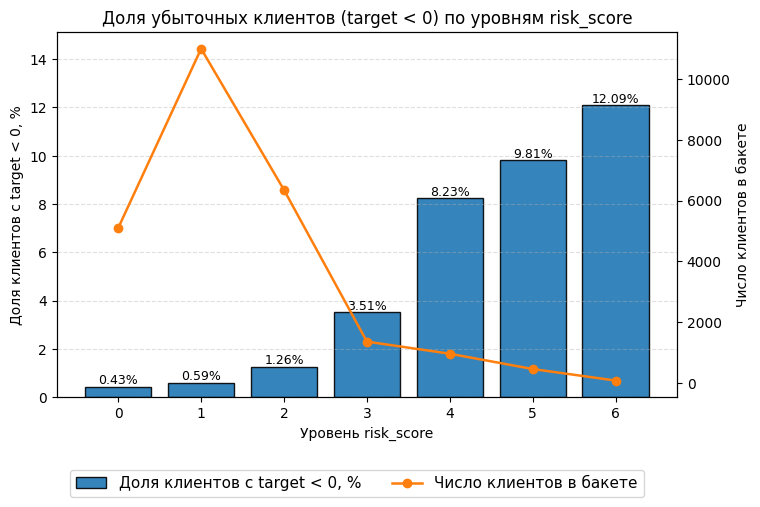

In [213]:
# Доля и количество "плохих" клиентов по уровням risk_score
share_by_score = (
    df.groupby("risk_score")
    .agg(
        share_bad=("is_bad", "mean"),
        n_users=("user_id", "count")
    )
    .reset_index()
    .sort_values("risk_score")
)

fig, ax1 = plt.subplots(figsize=(8, 5))

bar_color = "#1f77b4"
line_color = "#ff7f0e"

# Столбцы: доля клиентов с target < 0 (в процентах)
bars = ax1.bar(
    share_by_score["risk_score"],
    share_by_score["share_bad"] * 100,
    color=bar_color,
    edgecolor="black",
    alpha=0.9,
    label="Доля клиентов с target < 0, %"
)
ax1.set_xlabel("Уровень risk_score")
ax1.set_ylabel("Доля клиентов с target < 0, %")
ax1.set_title("Доля убыточных клиентов (target < 0) по уровням risk_score")

y_max = (share_by_score["share_bad"] * 100).max()
ax1.set_ylim(0, y_max * 1.25)

# Подписи над столбцами
for x, y in zip(share_by_score["risk_score"], share_by_score["share_bad"] * 100):
    ax1.text(x, y, f"{y:.2f}%", ha="center", va="bottom", fontsize=9)

# Сетка по Y
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# Вторая ось: число клиентов в каждом бакете risk_score
ax2 = ax1.twinx()
line = ax2.plot(
    share_by_score["risk_score"],
    share_by_score["n_users"],
    color=line_color,
    marker="o",
    markersize=6,
    linewidth=1.8,
    label="Число клиентов в бакете"
)
ax2.set_ylabel("Число клиентов в бакете")

# Легенда под графиком
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles = handles1 + handles2
labels = labels1 + labels2

fig.subplots_adjust(bottom=0.15)

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.02),
    ncol=2,
    frameon=True,
    fontsize=11
)

plt.show()


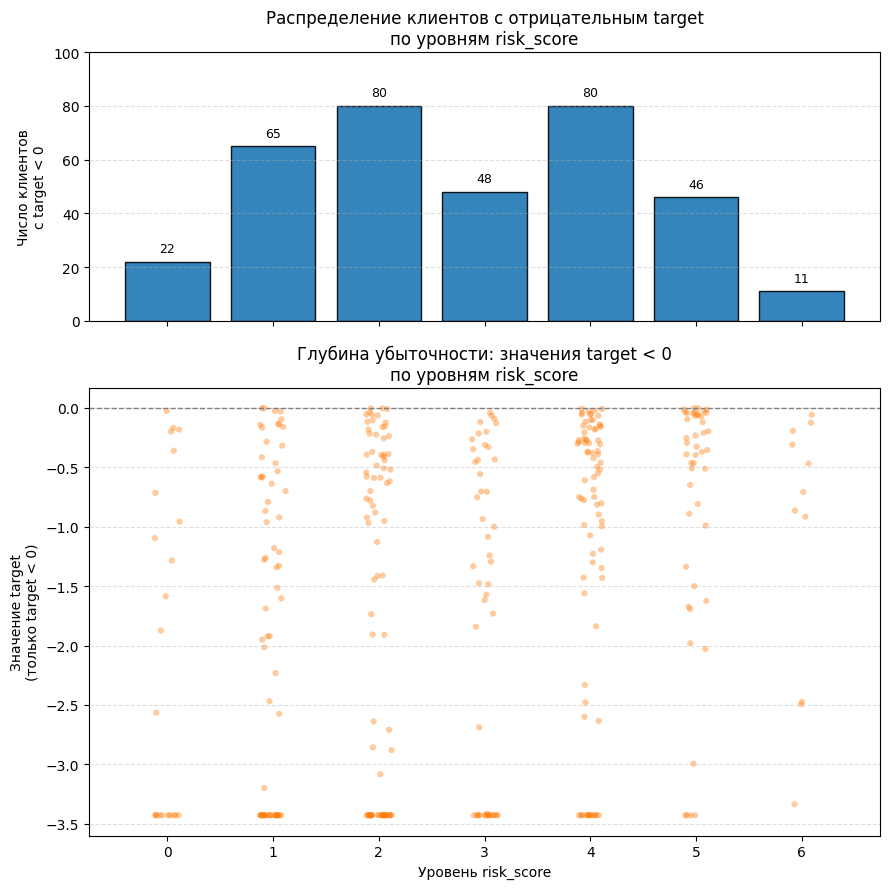

In [214]:
# Берём только клиентов с отрицательным target
bad = df[df["target"] < 0].copy()

scores_sorted = sorted(bad["risk_score"].unique())

# Число "плохих" клиентов в каждом уровне risk_score
bad_counts = (
    bad["risk_score"]
    .value_counts()
    .reindex(scores_sorted, fill_value=0)
)

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(9, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [1.2, 2]}
)

# Верхний график: сколько клиентов с target < 0 в каждом бакете risk_score

bar_color = "#1f77b4"

ax1.bar(
    scores_sorted,
    bad_counts.values,
    color=bar_color,
    edgecolor="black",
    alpha=0.9
)
ax1.set_ylabel("Число клиентов\nс target < 0")
ax1.set_title("Распределение клиентов с отрицательным target\nпо уровням risk_score")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

max_cnt = bad_counts.max()
ax1.set_ylim(0, max_cnt * 1.25)

# Подписи количества клиентов над столбцами
for x, cnt in zip(scores_sorted, bad_counts.values):
    ax1.text(
        x,
        cnt + max_cnt * 0.03,
        f"{cnt}",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax1.set_xticks(scores_sorted)
ax1.tick_params(axis="x", which="both", labelbottom=False)

# Нижний график: насколько глубоко уходит target (scatter только для target < 0)

point_color = "#ff7f0e"

xs = []
ys = []

jitter = 0.12

for s in scores_sorted:
    vals = bad.loc[bad["risk_score"] == s, "target"].values
    if len(vals) == 0:
        continue
    xs.extend(s + np.random.uniform(-jitter, jitter, size=len(vals)))
    ys.extend(vals)

ax2.scatter(
    xs,
    ys,
    alpha=0.4,
    color=point_color,
    s=20,
    edgecolors="none"
)

# Линия target = 0 как визуальная граница
ax2.axhline(0, linestyle="--", color="grey", linewidth=1)

ax2.set_ylabel("Значение target\n(только target < 0)")
ax2.set_xlabel("Уровень risk_score")
ax2.set_title("Глубина убыточности: значения target < 0\nпо уровням risk_score")
ax2.grid(axis="y", linestyle="--", alpha=0.4)

# Ось X — уровни risk_score
ax2.set_xticks(scores_sorted)

fig.subplots_adjust(hspace=0.4)

fig.tight_layout()
plt.show()


In [215]:
# Базовая таблица сопряжённости: risk_score × is_bad
ct_raw = pd.crosstab(df["risk_score"], df["is_bad"])

# χ²-критерий Пирсона на исходной таблице
chi2_stat, p_chi2, dof, expected = stats.chi2_contingency(ct_raw)

# Переименуем колонки is_bad
ct = ct_raw.rename(columns={
    False: "target ≥ 0",
    True:  "target < 0",
})

# Добавим по строкам общее количество и долю клиентов с target < 0
ct["Всего"] = ct.sum(axis=1)
ct["Доля target < 0, %"] = (ct["target < 0"] / ct["Всего"] * 100)

# Добавим строку "Всего" по всем risk_score
total_row = pd.DataFrame({
    "target ≥ 0": [ct["target ≥ 0"].sum()],
    "target < 0": [ct["target < 0"].sum()],
    "Всего":       [ct["Всего"].sum()],
    "Доля target < 0, %": [np.nan],
}, index=["Всего"])

ct_display = pd.concat([ct, total_row])

print("Таблица сопряжённости (risk_score × is_bad):")

styled_ct = (
    ct_display
        .style
        .set_table_attributes('style="width:100%; table-layout:fixed; border-collapse:collapse;"')
        .format({"Доля target < 0, %": "{:.2f}"})
        .background_gradient(
            cmap="Blues",
            subset=["target ≥ 0", "target < 0", "Всего"],
            low=0.1,
            high=0.9,
        )
        .set_caption(
            "Частоты и доля клиентов с отрицательным target\nпо уровням risk_score"
        )
        .set_table_styles([
            # заголовки по центру
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "4px 8px"),
                ],
            },
            # ячейки — чуть больше воздуха
            {
                "selector": "td",
                "props": [
                    ("padding", "4px 8px"),
                ],
            },
        ])
)

display(styled_ct)

alpha = 0.05

result_md = f"""
**Критерий хи-квадрат Пирсона для проверки зависимости `is_bad` от `risk_score`**

- Статистика χ²: **{chi2_stat:.2f}**
- Степени свободы: **{dof}**
- p-value: **{p_chi2:.3e}**
- Уровень значимости: **α = {alpha:.2f}**

Так как p-value значительно меньше уровня значимости α, **отклоняем нулевую гипотезу независимости**.  

Это означает, что вероятность того, что клиент окажется убыточным (`target < 0`), статистически значимо **зависит** от уровня его интегрального риск-балла `risk_score`.
"""

display(Markdown(result_md))


Таблица сопряжённости (risk_score × is_bad):


,target ≥ 0,target < 0,Всего,"Доля target < 0, %"
0,5078,22,5100,0.43
1,10918,65,10983,0.59
2,6267,80,6347,1.26
3,1321,48,1369,3.51
4,892,80,972,8.23
5,423,46,469,9.81
6,80,11,91,12.09
Всего,24979,352,25331,nan



**Критерий хи-квадрат Пирсона для проверки зависимости `is_bad` от `risk_score`**

- Статистика χ²: **781.24**
- Степени свободы: **6**
- p-value: **1.739e-165**
- Уровень значимости: **α = 0.05**

Так как p-value значительно меньше уровня значимости α, **отклоняем нулевую гипотезу независимости**.  

Это означает, что вероятность того, что клиент окажется убыточным (`target < 0`), статистически значимо **зависит** от уровня его интегрального риск-балла `risk_score`.


In [216]:
# Коэффициент ранговой корреляции Спирмена между risk_score и is_bad
rho_spear, p_spear = stats.spearmanr(df["risk_score"], df["is_bad"])

alpha = 0.05

text = f"""
**Коэффициент ранговой корреляции Спирмена**

Анализируемая пара признаков:
- интегральный риск-балл `risk_score` (порядковый признак),
- бинарный признак убыточности `is_bad` (1, если target < 0; 0 иначе).

Численные результаты:
- коэффициент Спирмена: **ρ = {rho_spear:.3f}**
- p-value: **{p_spear:.3e}**
- уровень значимости: **α = {alpha:.2f}**

**Гипотезы.**

- Нулевая гипотеза H0: между `risk_score` и `is_bad` **нет монотонной связи** (ρ = 0).
- Альтернативная гипотеза H1: при увеличении `risk_score` вероятность `is_bad = 1` **возрастает** (ρ > 0).

Так как p-value значительно меньше уровня значимости α, мы **отклоняем нулевую гипотезу H0** и принимаем H1.

Это означает, что существует статистически значимая **положительная монотонная связь**: при росте интегрального риск-балла `risk_score` доля убыточных клиентов (`target < 0`) в среднем увеличивается.
"""

display(Markdown(text))



**Коэффициент ранговой корреляции Спирмена**

Анализируемая пара признаков:
- интегральный риск-балл `risk_score` (порядковый признак),
- бинарный признак убыточности `is_bad` (1, если target < 0; 0 иначе).

Численные результаты:
- коэффициент Спирмена: **ρ = 0.113**
- p-value: **3.608e-72**
- уровень значимости: **α = 0.05**

**Гипотезы.**

- Нулевая гипотеза H0: между `risk_score` и `is_bad` **нет монотонной связи** (ρ = 0).
- Альтернативная гипотеза H1: при увеличении `risk_score` вероятность `is_bad = 1` **возрастает** (ρ > 0).

Так как p-value значительно меньше уровня значимости α, мы **отклоняем нулевую гипотезу H0** и принимаем H1.

Это означает, что существует статистически значимая **положительная монотонная связь**: при росте интегрального риск-балла `risk_score` доля убыточных клиентов (`target < 0`) в среднем увеличивается.


## Результаты проверки гипотезы 1 о связи `risk_score` и отрицательного target

### 1. Описательная статистика и графики

По сводной таблице и комбинированному графику (столбцы — доля клиентов с `target < 0`, линия — число клиентов в бакете) видно, что:

- основная масса клиентов сосредоточена в низких значениях `risk_score` (0–2); уровни 4–6 представлены заметно меньшим числом пользователей, поэтому интерпретировать их нужно осторожнее;
- доля клиентов с отрицательным `target` (`target < 0`) **монотонно растёт** с увеличением `risk_score`: от долей процента при `risk_score = 0` до нескольких процентов при `risk_score = 2–3` и двузначных значений для самых высоких уровней `risk_score`.

То есть вероятность «плохого» месяца по возвратам у клиентов с высоким `risk_score` в разы выше, чем у клиентов без сработавших риск-признаков.

Отдельная визуализация только для клиентов с `target < 0` (верхний график — количество таких клиентов по уровням `risk_score`, нижний — диаграмма рассеяния глубины отрицательных значений `target`) показывает, что:

- клиенты с `target < 0` встречаются практически во всех группах `risk_score`, но их концентрация явно выше в сегментах с более высоким риск-баллом;
- в бакетах с высоким `risk_score` не только больше клиентов с отрицательным `target`, но и сами значения `target` уходят **глубже в минус** — на диаграмме заметны точки, существенно ниже уровня 0, что соответствует сильно убыточным месяцам;
- для экстремальных уровней `risk_score` (максимальные значения) количество наблюдений невелико, поэтому по ним корректнее делать качественные, а не строгие количественные выводы.

В совокупности эти графики подтверждают, что интегральный риск-балл `risk_score` действительно связан и с **вероятностью наступления убыточного месяца**, и с **глубиной потенциального убытка** для клиента.

### 2. Критерий хи-квадрат Пирсона

Для проверки независимости категориальных признаков `risk_score` и `is_bad` (где `is_bad = 1`, если `target < 0`) применён критерий хи-квадрат Пирсона по таблице сопряжённости `risk_score × is_bad`.

Результаты расчёта:

- значение статистики хи-квадрат: **χ² ≈ 781,24**;
- число степеней свободы: **6**;
- p-value: **≈ 1,74 · 10⁻¹⁶⁵**, то есть существенно меньше 0,001.

При уровне значимости α = 0,05:

- p-value намного меньше α,
- следовательно, нулевая гипотеза H₀ об отсутствии связи между `risk_score` и `is_bad` уверенно отвергается.

Это означает, что распределение признака `is_bad` (есть ли отрицательный target) статистически значимо **зависит** от уровня интегрального балла риска `risk_score`.

### 3. Корреляция Спирмена

Дополнительно оценим монотонную связь между числовым `risk_score` и бинарным признаком `is_bad` (0/1) с помощью коэффициента ранговой корреляции Спирмена.

Гипотезы:

- H0: между `risk_score` и `is_bad` **нет монотонной связи** (ρ = 0).
- H1: при увеличении `risk_score` вероятность `is_bad = 1` **возрастает** (ρ > 0).

По результатам расчёта:

- коэффициент Спирмена: **ρ ≈ 0,11**;
- p-value: **существенно меньше 0,001** (значительно ниже уровня значимости α = 0,05).

Интерпретация:

- положительный знак коэффициента означает, что при увеличении `risk_score` вероятность `is_bad = 1` (то есть `target < 0`) в среднем **увеличивается**;
- величина ρ около 0,11 соответствует **слабой, но статистически значимой монотонной связи**. Это ожидаемо: убыточность клиента определяется не одним фактором, а совокупностью поведенческих признаков, поэтому интегральный риск-балл `risk_score` даёт не жёсткую сегментацию, а именно вероятностный сдвиг в сторону более рискованного поведения.

### Заключение по гипотезе 1: "интегральный `risk_score` связан с вероятностью отрицательного target"

Гипотеза **подтверждается**.

1. По описательной статистике и визуализациям видно, что доля клиентов с отрицательным `target` систематически возрастает с ростом интегрального `risk_score`.

2. Критерий хи-квадрат Пирсона по таблице сопряжённости `risk_score × is_bad` показывает статистически значимую зависимость между `risk_score` и `is_bad`.

3. Коэффициент ранговой корреляции Спирмена даёт положительное значение при крайне малом p-value, что подтверждает наличие слабой, но устойчивой монотонной связи: чем выше `risk_score`, тем выше риск того, что клиент окажется убыточным (имеет `target < 0`) в следующем месяце.

С точки зрения продукта и ML-задачи это означает, что:

- собранный набор исторических риск-признаков и интегральный `risk_score` действительно **информативны** для прогнозирования будущей убыточности клиентов;
- `risk_score` можно использовать:
  - как понятный бизнесу скоринговый индикатор в дашбордах и отчётах;
  - как дополнительный (агрегирующий) признак в модели прогнозирования прибыльности/убыточности клиента;
  - как основу для правил риск-менеджмента: ограничения промо-активности, приоритизации модерации, специальных сценариев обработки high-risk клиентов.


# Гипотеза 2

Проанализируем клиентов в контексте исторических возвратов.

Будем работать с подмножеством клиентов, у которых вообще есть исторические возвраты:

In [217]:
df_hist_return_exists =  df.dropna(subset='hist_return_rate')
print(df_hist_return_exists['user_id'].count())
df_hist_return_exists.head(6)

5247


,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return,hist_return_rate,...,lag_days,lag_bucket,risk_lag,total_buy_bucket,risk_buy,risk_2d,risk_score,target_unshifted,is_bad_target,is_bad
2,user_000002,5,2025-01-19,2025-01-23,browser_02,2025-02-20,0.30,194.61,485.00,2.49,...,28.00,16–176 дней,False,53–203,False,False,1,0.00,False,False
9,user_000009,3,2025-01-22,2025-01-29,browser_01,2025-01-30,0.00,8.50,62.67,7.37,...,1.00,0–5 дней,False,0–19,False,False,2,0.30,True,False
17,user_000017,3,2025-03-28,2024-05-21,browser_05,2025-03-13,0.00,226.49,40.00,0.18,...,296.00,177–687 дней,True,204–999,False,False,2,0.30,True,False
27,user_000027,6,2025-01-27,2025-01-20,browser_02,2025-01-11,0.00,101.26,401.00,3.96,...,-9.00,lag < 0,True,53–203,False,False,3,0.30,True,False
29,user_000029,8,2025-03-30,2023-12-12,browser_02,2025-03-19,0.00,6.85,111.25,16.24,...,463.00,177–687 дней,True,0–19,False,False,2,0.30,True,False
30,user_000030,5,2025-03-24,2024-12-19,browser_08,2025-03-30,0.00,6516.05,4830.00,0.74,...,101.00,16–176 дней,False,>2726,True,True,3,0.30,True,False


Посмотрим, что представляет из себя распределение клиентов по историческим возвратам

Медиана: 0.6329757269145337


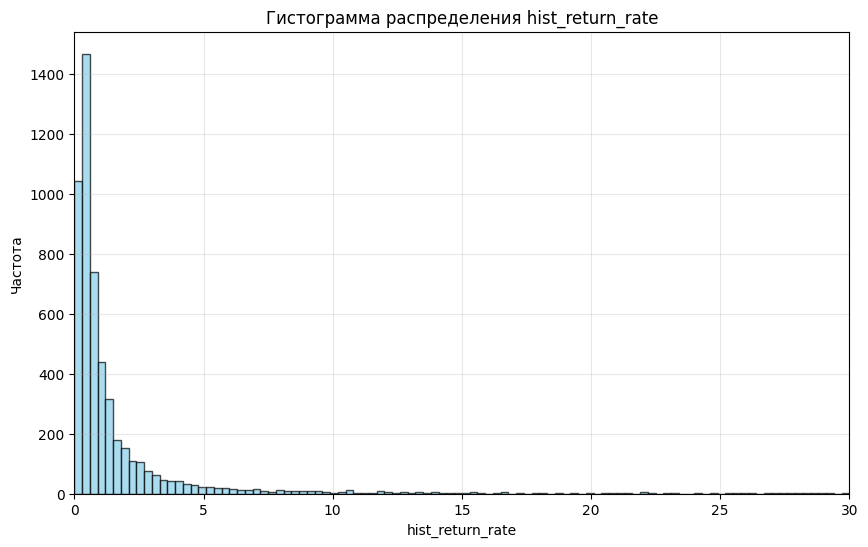

In [218]:
import matplotlib.pyplot as plt
import numpy as np

## Вычислим медиану по hist_return_rate
print(f"Медиана: {df_hist_return_exists['hist_return_rate'].median()}")


## Построим диаграмму распределения
plt.figure(figsize=(10, 6))


bin_edges = np.linspace(0, 30, num=101)
plt.hist(
    df_hist_return_exists['hist_return_rate'],
    bins=bin_edges,
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)


plt.xlabel('hist_return_rate')
plt.ylabel('Частота')
plt.xlim(0, 30)
plt.ylim(bottom=0)
plt.title('Гистограмма распределения hist_return_rate')
plt.grid(True, alpha=0.3)
plt.show()


Из графика и расчета медианы очевидно, что распределение не нормальное, и что у половины клиентов исторический возврат не превышает 0,63.

Разобьем клиентов с историческим возвратом на две группы (справа и слева от медианы), и посмотрим, нет ли каких-то особенностей у этих групп

Начнем с количества устройств. Определим вид распределения в подгруппах по количеству исторических возвратов (strange: hist_return_rate>=0.63; ok: hist_return_rate<0.63>):

In [219]:
df_strange_hist_return = (df_hist_return_exists[df_hist_return_exists['hist_return_rate']>=0.63])['platform_num']
df_ok_hist_return = (df_hist_return_exists[df_hist_return_exists['hist_return_rate']<0.63])['platform_num']

df_strange_hist_return_std = stats.zscore(df_strange_hist_return)
df_ok_hist_return_std = stats.zscore(df_ok_hist_return)

_, p_value_strange = stats.kstest(df_strange_hist_return_std, 'norm')
_, p_value_ok = stats.kstest(df_ok_hist_return_std, 'norm')

print(f'bad_target is norm: {p_value_strange >= 0.05}')
print(f'good_target is norm: {p_value_ok >= 0.05}')


bad_target is norm: False
good_target is norm: False


Видим, значения в подгруппах не распределены нормально, а значит, для их сравнения нужно использовать непараметрических критерий. Сравним количество устройств в подгруппах с использованием U-критерия Манна-Уитни, который удовлетворяет нашему требованию по пригодности для выборок, не согласующихся с нормальным законом:

U-value: 2505215.5000
p-значение: 0.0000
Медианное число устройств у пользователей с большим количеством возвратов: 4.0
Медианное число устройств у пользователей с приемлемым количеством возвратов: 6.0


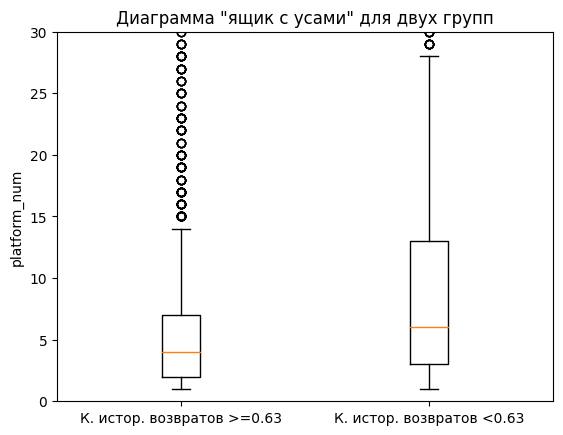

In [220]:
res = stats.mannwhitneyu(df_strange_hist_return, df_ok_hist_return, alternative='two-sided')
print(f"U-value: {res.statistic:.4f}")
print(f"p-значение: {res.pvalue:.4f}")

print(f"Медианное число устройств у пользователей с большим количеством возвратов: {df_strange_hist_return.median()}")
print(f"Медианное число устройств у пользователей с приемлемым количеством возвратов: {df_ok_hist_return.median()}")


# Строим boxplot
plt.boxplot([df_strange_hist_return, df_ok_hist_return], labels=['К. истор. возвратов >=0.63', 'К. истор. возвратов <0.63'])
plt.title('Диаграмма "ящик с усами" для двух групп')
plt.ylim(0,30)
plt.ylabel('platform_num')
plt.show()

###  Отсюда делаем вывод:
- Пользователи, которые меньше возвращали заказов в прошлом, имеют больше привязанных аккаунтов к устройству (медианное значение: 6 против 4)

### Далее рассмотрим исторические возвраты более абстрактно - нет ли корреляции между количеством устройств и уровнем возвратов в прошлом?


**Вычислим корреляцию по Спирмену:**

In [221]:
platform_num_hist_return_corr_obj = stats.spearmanr(df_hist_return_exists['platform_num'], df_hist_return_exists['hist_return_rate'])
p_value = platform_num_hist_return_corr_obj[1]
corr_value = platform_num_hist_return_corr_obj[0]

print(f'p-value: {p_value:.4f}; corr: {corr_value:.4f}')


p-value: 0.0000; corr: -0.2469


Видим, что между количеством устройств и уровнем исторических возвратов существует статистически значимая слабая обратная корреляция

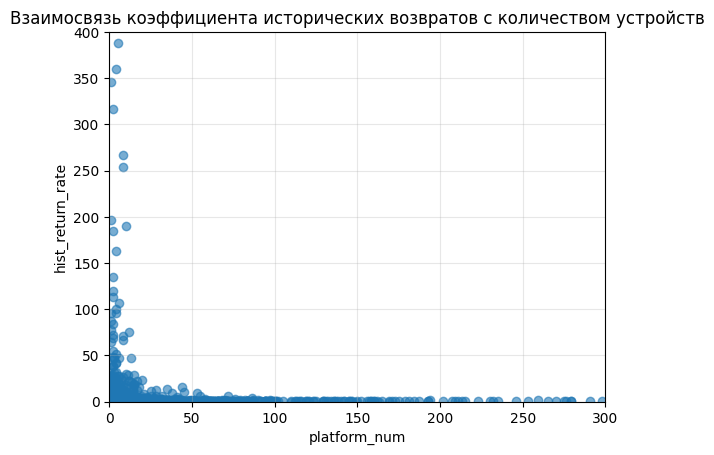

In [222]:
## График

plt.scatter(df_hist_return_exists['platform_num'], df_hist_return_exists['hist_return_rate'], alpha=0.6)

# Оформляем график
plt.xlabel('platform_num')
plt.ylabel('hist_return_rate')
plt.xlim(0, 300)
plt.ylim(0, 400)
plt.title('Взаимосвязь коэффициента исторических возвратов с количеством устройств')
plt.grid(True, alpha=0.3)
plt.show()

### Отсюда делаем выводы:
- Количество возвратов в прошлом имеет слабую обратную корреляцию с количеством устройств, привязанных к аккаунту
- Пользователи с большим количеством привязанных устройств делали меньше возвратов в прошлом

## Заключение по гипотезе 2: 

Даже если предположить, что аккаунты с большим количеством привязанных устройств используются несколькими людьми, они скорее выгодны бизнесу, чем опасны. Возможно, что это не несколько человек за одним аккаунтом, а просто очень лояльный пользователь, который посещает маркетплейс с рабочего пк, смартфона, домашнего пк, планшета, и тд, то есть, в целом с большего количества устройств. Черта "токсичного" клиента - малое количество привязанных устройств, что подтверждается как попарным анализом, так и установленной слабой корреляцией

# Гипотеза 3

Методология проверки гипотезы

Чтобы понять, влияет ли браузер на метрику target, действуем по следующему алгоритму:
1. Тип данных: У нас количественная переменная (target) и больше двух сравниваемых групп (разные браузеры), поэтому выбор стоит между параметрическим тестом (ANOVA) и непараметрическим (Краскела-Уоллиса).
2. Проверка условий:
    - Запускаем тест Шапиро-Уилка для проверки нормальности распределения.
    - Запускаем тест Левена для проверки равенства дисперсий (разброса данных) в группах.
3. Выбор критерия:
    - Если данные распределены нормально и дисперсии равны применяем ANOVA.
    - Если распределение отличается от нормального или дисперсии не равны (что часто бывает с данными о покупках) применяем тест Краскела-Уоллиса.

Если выбранный тест покажет статистическую значимость ($p < 0.05$), это будет означать, что поведение пользователей в разных браузерах действительно различается.

In [223]:
# Убираем пустые значения и формируем списки по группам
df_clean = df.dropna(subset=['browser', 'total_return'])

# Фильтрация: Оставляем только браузеры, где есть хотя бы 30 пользователей.
# Тесты на малых группах не имеют статистической силы и создают шум
browser_counts = df_clean['browser'].value_counts()
valid_browsers = browser_counts[browser_counts >= 30].index
df_final = df_clean[df_clean['browser'].isin(valid_browsers)]

# Формируем данные для теста: список списков значений total_return по каждому браузеру
groups = [group['total_return'].values for name, group in df_final.groupby('browser')]
print(f"Анализ по {len(groups)} группам (браузерам с N >= 30).")

# Проверка условий
alpha = 0.05

# 1. Проверка нормальности Шапиро-Уилка
# Если p < 0.05, значит распределение не нормальное
is_normal = True
for g in groups:
    # Берём выборку для теста Шапиро-Уилка (максимум 5000 элементов)
    sample = g[:5000] if len(g) > 5000 else g
    stat, p = stats.shapiro(sample)
    if p < alpha:
        is_normal = False
        break

# 2. Проверка равенства дисперсий Левена
# Если p < 0.05 значит дисперсии (разброс) НЕ равны
stat_levene, p_levene = stats.levene(*groups)
is_homogenic = p_levene > alpha

print(f"\nРезультаты проверки:")
print(f"1. Нормальность распределения: {'Соблюдается' if is_normal else 'Не соблюдается'}")
print(f"2. Равенство дисперсий (p={p_levene:.5f}): {'Соблюдается' if is_homogenic else 'Не соблюдается'}")

# Выбор и проведение теста
print(f"\n{'-'*40}")
if is_normal and is_homogenic:
    test_name = "ANOVA"
    stat, p_value = stats.f_oneway(*groups)
    print(f"Выбран тест: {test_name} (условия выполнены)")
else:
    test_name = "Критерий Краскела-Уоллиса (H-тест)"
    stat, p_value = stats.kruskal(*groups)
    print(f"Выбран тест: {test_name} (так как нарушена нормальность или дисперсии)")

print(f"{'-'*40}")
print(f"Статистика критерия: {stat:.4f}")
print(f"P-value: {p_value:.5f}")

# Вывод
print(f"{'-'*40}")
if p_value < alpha:
    print("Результат: Отвергаем H0")
    print("Обнаружены статистически значимые различия в исторических возвратах пользователей разных браузеров")
else:
    print("РЕЗУЛЬТАТ: Не отвергаем H0")
    print("Тип браузера не оказывает значимого влияния на исторические возвраты (total_return)")

Анализ по 20 группам (браузерам с N >= 30).

Результаты проверки:
1. Нормальность распределения: Не соблюдается
2. Равенство дисперсий (p=0.00000): Не соблюдается

----------------------------------------
Выбран тест: Критерий Краскела-Уоллиса (H-тест) (так как нарушена нормальность или дисперсии)
----------------------------------------
Статистика критерия: 252.6710
P-value: 0.00000
----------------------------------------
Результат: Отвергаем H0
Обнаружены статистически значимые различия в исторических возвратах пользователей разных браузеров


In [224]:
df_clean = df.dropna(subset=['browser', 'total_return']).copy()

# Оставляем только браузеры, где >= 30 пользователей
browser_counts = df_clean['browser'].value_counts()
valid_browsers = browser_counts[browser_counts >= 30].index
df_final = df_clean[df_clean['browser'].isin(valid_browsers)].copy()

# Попарное сравнение браузеров
print("\n1. Попарное сравнение браузеров (Тест Данна с поправкой Бонферрони)")
try:
    p_values = sp.posthoc_dunn(df_final, val_col='total_return', group_col='browser', p_adjust='bonferroni')

    # Фильтруем и показываем только значимые различия
    significant_pairs = p_values[p_values < 0.05].stack().reset_index()
    significant_pairs.columns = ['Browser A', 'Browser B', 'p-value']

    # Убираем дубликаты пар и сравнение с самим собой
    significant_pairs = significant_pairs[significant_pairs['Browser A'] < significant_pairs['Browser B']]

    print(f"Количество значимых различий: {len(significant_pairs)}")
    if len(significant_pairs) > 0:
        display(significant_pairs.head(10))
    else:
        print("Значимых различий не найдено.")

except Exception as e:
    print(f"Ошибка в тесте Данна: {e}")

# АНАЛИЗ
# А) Тест Хи-квадрат: Влияет ли браузер на вероятность возврата?
df_final['has_return'] = (df_final['total_return'] > 0).astype(int)
contingency_table = pd.crosstab(df_final['browser'], df_final['has_return'])

chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\n2. Тест Хи-квадрат (Частота возвратов):")
print(f"p-value = {p_chi2:.5f} {'Различия значимы' if p_chi2 < 0.05 else 'Различий НЕТ'}")

# Б) Краскел-Уоллис: Влияет ли браузер на СУММУ возврата (среди тех, кто вернул)
df_returners = df_final[df_final['total_return'] > 0]

if len(df_returners) > 0:
    groups_amount = [g['total_return'].values for n, g in df_returners.groupby('browser')]
    if len(groups_amount) > 1:
        stat_amount, p_amount = stats.kruskal(*groups_amount)
        print(f"\n3. Тест Краскела-Уоллиса (Средний чек возврата):")
        print(f"p-value = {p_amount:.5f} {'Различия значимы' if p_amount < 0.05 else 'Различий НЕТ'}")
    else:
        print("\n3. Недостаточно групп для сравнения сумм.")
else:
    print("\n3. Нет пользователей с возвратами.")


1. Попарное сравнение браузеров (Тест Данна с поправкой Бонферрони)
Количество значимых различий: 25


,Browser A,Browser B,p-value
0,browser_00,browser_01,0.00
1,browser_00,browser_05,0.00
2,browser_00,browser_06,0.00
3,browser_00,browser_10,0.01
5,browser_01,browser_02,0.00
6,browser_01,browser_03,0.00
7,browser_01,browser_04,0.00
8,browser_01,browser_08,0.00
9,browser_01,browser_09,0.00
10,browser_01,browser_11,0.05



2. Тест Хи-квадрат (Частота возвратов):
p-value = 0.00000 Различия значимы

3. Тест Краскела-Уоллиса (Средний чек возврата):
p-value = 0.00000 Различия значимы


In [225]:
print("Визуализация распределения исторических возвратов по браузерам")

# Подготовка данных для визуализации
# Берём топ-10 браузеров по количеству пользователей
top_browsers = df_final['browser'].value_counts().head(10).index.tolist()
df_viz = df_final[df_final['browser'].isin(top_browsers)].copy()

# Вычисляем статистики по браузерам
browser_stats = df_viz.groupby('browser')['total_return'].agg(['mean', 'median', 'std', 'count']).reset_index()
browser_stats.columns = ['Браузер', 'Среднее', 'Медиана', 'Ст.откл.', 'Кол-во']
browser_stats = browser_stats.sort_values('Медиана', ascending=False)

print("\nСтатистики исторических возвратов по браузерам (топ-10)")
display(browser_stats)

# Сортируем по медиане для лучшей визуализации
order = browser_stats['Браузер'].tolist()

# Фильтруем данные для визуализации (убираем экстремальные выбросы)
q99 = df_viz['total_return'].quantile(0.99)
df_viz_filtered = df_viz[df_viz['total_return'] <= q99]

Визуализация распределения исторических возвратов по браузерам

Статистики исторических возвратов по браузерам (топ-10)


,Браузер,Среднее,Медиана,Ст.откл.,Кол-во
0,browser_00,516.23,0.00,3801.48,1096
1,browser_01,324.56,0.00,2003.56,4099
2,browser_02,213.86,0.00,1671.49,9500
3,browser_03,502.41,0.00,4449.46,5788
4,browser_04,67.99,0.00,435.26,624
5,browser_05,400.46,0.00,1822.83,366
6,browser_06,309.14,0.00,1582.70,561
7,browser_09,542.69,0.00,4253.35,1563
8,browser_10,126.44,0.00,592.15,382
9,browser_15,407.13,0.00,2875.66,323


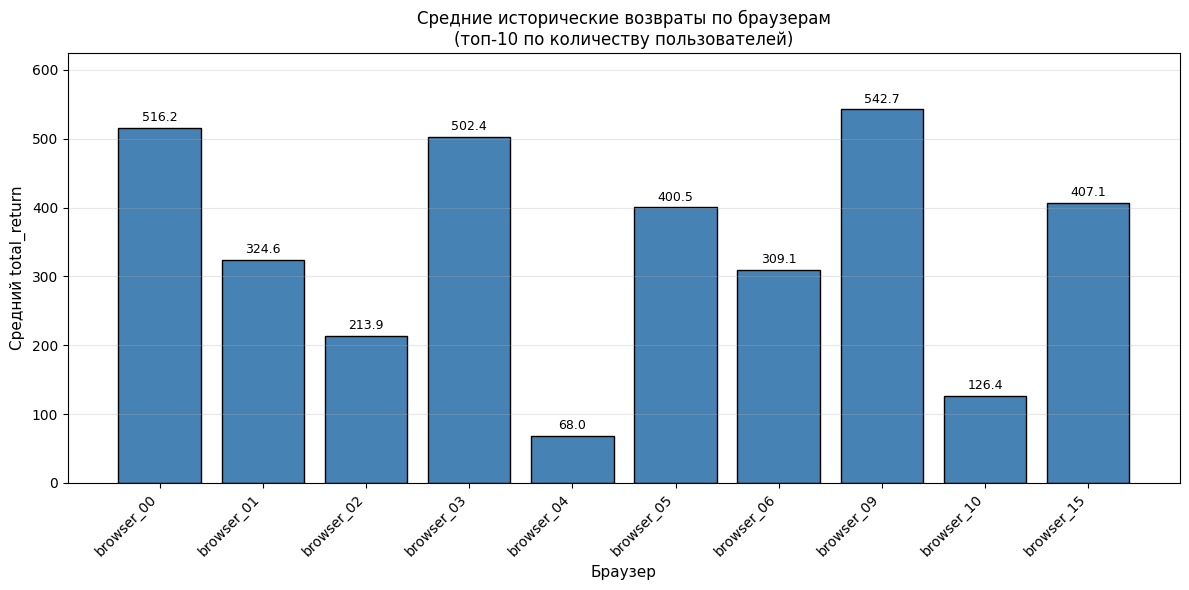

In [226]:
# Средние исторические возвраты по браузерам
fig, ax = plt.subplots(figsize=(12, 6))

# Строим столбчатую диаграмму
bars = ax.bar(range(len(browser_stats)), browser_stats['Среднее'], color='steelblue', edgecolor='black')

# Настройки графика
ax.set_title('Средние исторические возвраты по браузерам\n(топ-10 по количеству пользователей)', fontsize=12)
ax.set_xlabel('Браузер', fontsize=11)
ax.set_ylabel('Средний total_return', fontsize=11)

# Настройка оси X
ax.set_xticks(range(len(browser_stats)))
ax.set_xticklabels(browser_stats['Браузер'], rotation=45, ha='right')

# Сетка
ax.grid(axis='y', alpha=0.3)

# Динамически увеличиваем предел оси Y на 15%
max_height = browser_stats['Среднее'].max()
ax.set_ylim(0, max_height * 1.15)

# Добавляем значения над столбцами
for i, (bar, val) in enumerate(zip(bars, browser_stats['Среднее'])):
    # Отступ текста = 1% от высоты графика
    ax.text(i, bar.get_height() + (max_height * 0.01), f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

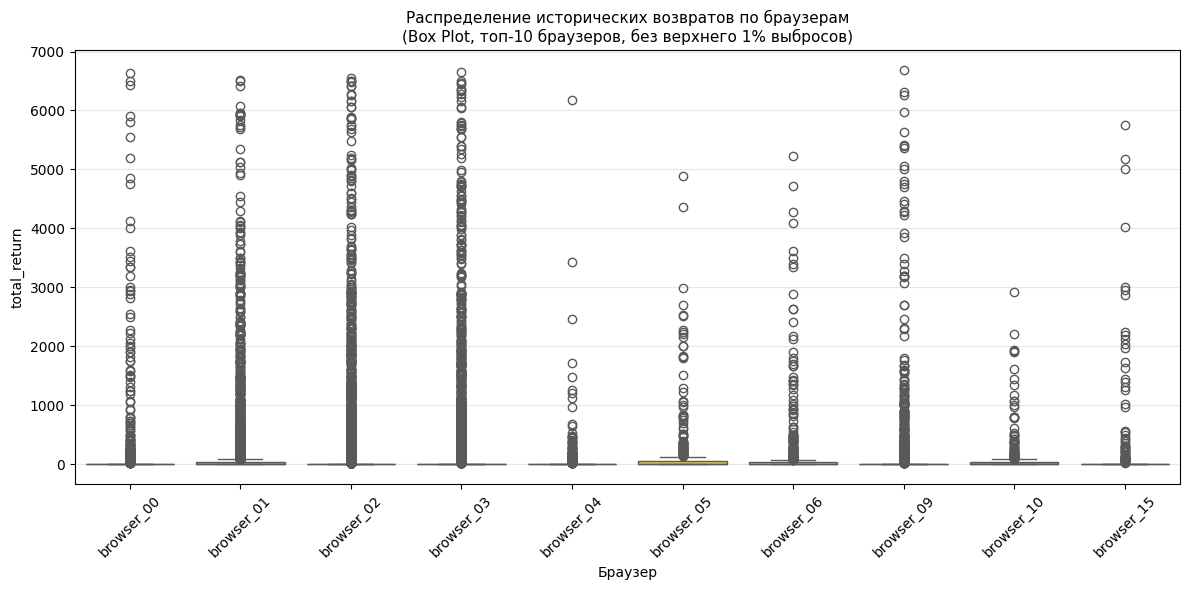

In [227]:
# Распределение исторических возвратов по браузерам
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(data=df_viz_filtered, x='browser', y='total_return', hue='browser',
            order=order, ax=ax, palette='Set2', legend=False)
ax.set_title('Распределение исторических возвратов по браузерам\n(Box Plot, топ-10 браузеров, без верхнего 1% выбросов)', fontsize=11)
ax.set_xlabel('Браузер', fontsize=10)
ax.set_ylabel('total_return', fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

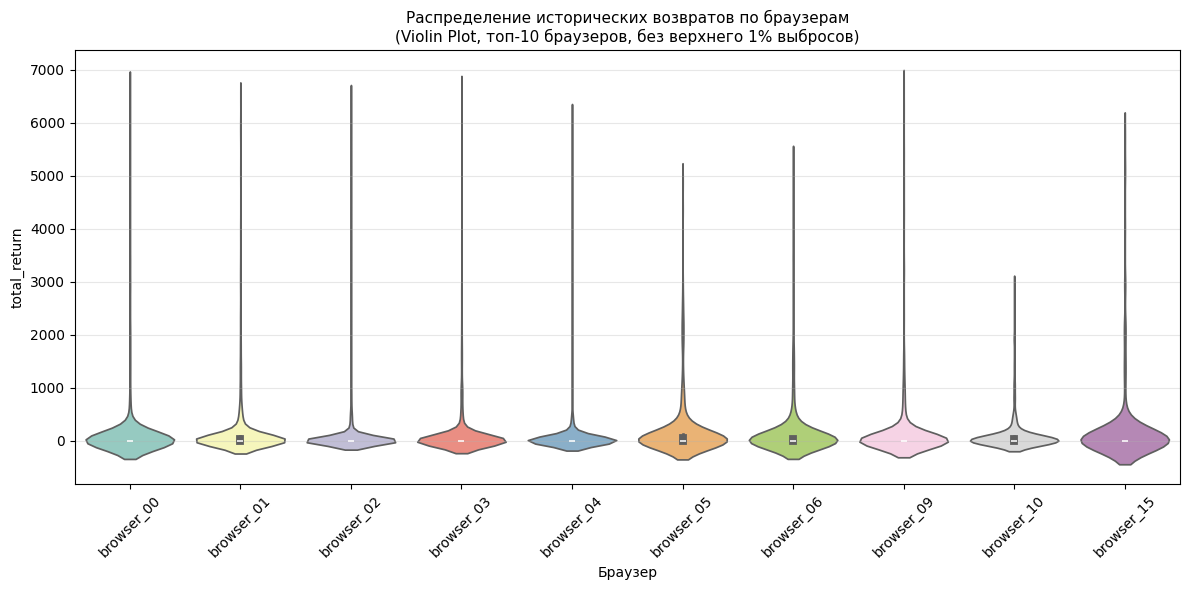

In [228]:
# Распределение исторических возвратов по браузерам
fig, ax = plt.subplots(figsize=(12, 6))

sns.violinplot(data=df_viz_filtered, x='browser', y='total_return', hue='browser',
               order=order, ax=ax, palette='Set3', legend=False)
ax.set_title('Распределение исторических возвратов по браузерам\n(Violin Plot, топ-10 браузеров, без верхнего 1% выбросов)', fontsize=11)
ax.set_xlabel('Браузер', fontsize=10)
ax.set_ylabel('total_return', fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

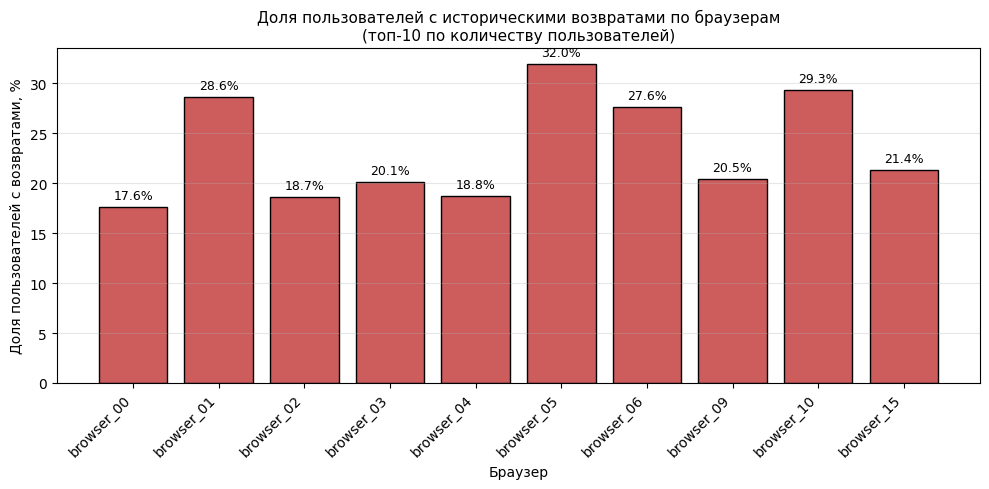

In [229]:
# Доля пользователей с возвратами
fig, ax = plt.subplots(figsize=(10, 5))

# Вычисляем долю пользователей с возвратами (total_return > 0)
return_rates = df_viz.groupby('browser')['total_return'].apply(
    lambda x: (x > 0).sum() / len(x) * 100
).reindex(order)

bars = ax.bar(range(len(return_rates)), return_rates.values, color='indianred', edgecolor='black')
ax.set_title('Доля пользователей с историческими возвратами по браузерам\n(топ-10 по количеству пользователей)', fontsize=11)
ax.set_xlabel('Браузер', fontsize=10)
ax.set_ylabel('Доля пользователей с возвратами, %', fontsize=10)
ax.set_xticks(range(len(return_rates)))
ax.set_xticklabels(return_rates.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Добавляем значения над столбцами
for i, (bar, val) in enumerate(zip(bars, return_rates.values)):
    ax.text(i, bar.get_height() + 0.5, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Заключение по гипотезе 3:


* Тип браузера не влияет на само решение пользователя вернуть товар.
* В «рискованных» браузерах (`browser_09`, `browser_00`) средний чек возврата (>500 ед.) в **5–8 раз выше**, чем в остальных (<100 ед.).
* Браузер маркирует специфический сегмент аудитории (вероятно, оптовики или реселлеры), а не технические проблемы.

# Гипотеза 4

Для начала бегло оценим, различается ли вообще количество устройств у "хороших" клиентов (target_unshifted < 0.3) и "плохих" (target_unshifted >= 0.3)

Первым делом, проверим выборки на нормальность c помощью критерия Колмогорова-Смирнова, чтобы корректно выбрать статистический критерий.


In [230]:
bad_target_devices = (df[df['is_bad_target']==True])['platform_num']
good_target_devices = (df[df['is_bad_target']==False])['platform_num']

bad_target_std = stats.zscore(bad_target_devices)
good_target_std = stats.zscore(good_target_devices)

_, p_value_bad = stats.kstest(bad_target_std, 'norm')
_, p_value_good = stats.kstest(good_target_std, 'norm')

print(f'bad_target is norm: {p_value_bad >= 0.05}')
print(f'good_target is norm: {p_value_good >= 0.05}')

bad_target is norm: False
good_target is norm: False


Наши выборки независимы, несогласуются с нормальным законом, и их две. Это значит, что для их сравнения подойдет U-критерий Манна-Уитни

U-value: 14709906.5000
p-значение: 0.0000
Медианное число устройств у пользователей с большим количеством возвратов: 3.0
Медианное число устройств у пользователей с приемлемым количеством возвратов: 6.0


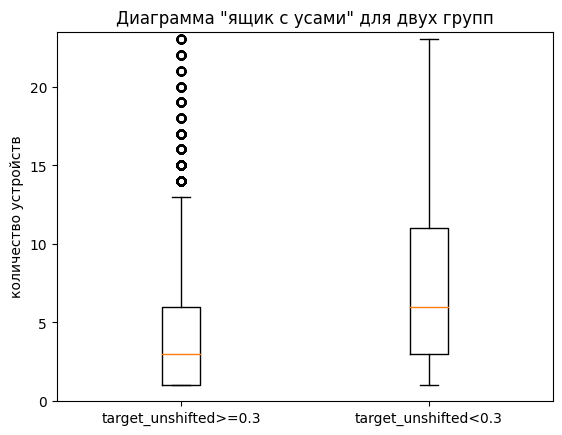

In [231]:
## разбиваем на группы
bad_target = df[df['is_bad_target']==True]
good_target = df[df['is_bad_target']==False]


##Проверяем по критерию манн-утни
res = stats.mannwhitneyu(bad_target['platform_num'], good_target['platform_num'], alternative='two-sided')
print(f"U-value: {res.statistic:.4f}")
print(f"p-значение: {res.pvalue:.4f}")

print(f"Медианное число устройств у пользователей с большим количеством возвратов: {bad_target['platform_num'].median()}")
print(f"Медианное число устройств у пользователей с приемлемым количеством возвратов: {good_target['platform_num'].median()}")


# Строим boxplot
plt.boxplot([bad_target['platform_num'], good_target['platform_num']], labels=['target_unshifted>=0.3', 'target_unshifted<0.3'])
plt.title('Диаграмма "ящик с усами" для двух групп')
plt.ylim(0,23.5)
plt.ylabel('количество устройств')
plt.show()

Наблюдаем статистически значимое различие в количестве устройств у "плохих" и "хороших" клиентов: медианное количество устройств у "хороших" вдвое больше, чем у "плохих" (6 против 3).
Таким образом, делаем вывод:

-  Пользователи, которые реже делают возвраты, в среднем сидят с большего количество устройств.

Проверим, есть ли статистически значимая корреляция между количеством устройств у пользователя и значением target

Статистически значимыми будем считать результаты при P < 0.05

In [232]:
## Считаем корреляция спирмена
target_unshifted_platform_corr_obj = stats.spearmanr(df['platform_num'], df['target_unshifted'])
p_value = target_unshifted_platform_corr_obj[1]
corr_value = target_unshifted_platform_corr_obj[0]

print(f'p-value: {p_value:.4f}; corr: {corr_value:.4f}')


p-value: 0.0000; corr: -0.1282


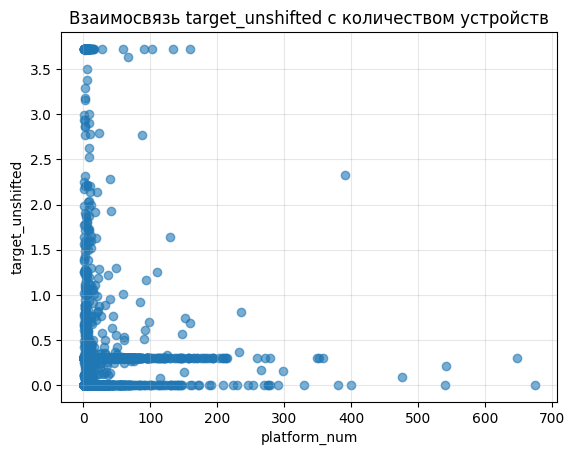

In [233]:
## График

plt.scatter(df['platform_num'], df['target_unshifted'], alpha=0.6)

# Оформляем график
plt.xlabel('platform_num')
plt.ylabel('target_unshifted')
plt.title('Взаимосвязь target_unshifted c количеством устройств')
plt.grid(True, alpha=0.3)
plt.show()

Наблюдаем статистически значимую слабую отрицательную корреляцию между platform_num и target_unshifted.

Таким образом, можем сделать выводы:
-  есть статистически значимая слабая взаимосвязь между количеством устройств и количеством возвратов
- чем больше устройств у аккаунта, тем ниже доля возвратов к покупкам

## Заключение по гипотезе 4:
Пользователи с большим количеством устройств менее "токсичны", чем таковые с меньшим количеством устройств, поскольку менее склонны делать возвраты покупок. Скорее всего большое количество привязанных устрйоств свидетельствует о большем интересе к сервису у пользователя: он заходит на него не только с домашнего ПК, но и со смартфона, планшета, рабочего ПК/учебного ПК и тд. Черта "токсичного" клиента - малое количество привязанных устройств, что подтверждается как попарным анализом, так и установленной слабой корреляцией

# Гипотеза 5

Изучим, как ведут себя “старые” и “новые” клиенты:
- есть ли разница в возвратах между теми, кто давно покупает на маркетплейсе,
- и теми, кто сделал первую покупку недавно (или вообще ещё не покупал).
В датасете нет явной даты среза, но есть дата первой покупки `first_buy`. Для всех пользователей, попавших в выборку на дату среза, чем раньше `first_buy`, тем старше клиент, поэтому можно использовать дату первой покупки как приближённую меру “возраста клиента”.


Вероятность возврата в ближайший месяц зависит от «возраста» клиента:
- существует различие в доле возвратов между когортами по дате первой покупки (`first_buy`).

Отдельно выделяем пользователей без первой покупки (у кого `first_buy` отсутствует) как отдельную когорту.


**Стратегия проверки гипотезы**

1. Уберём смещение 0.3 из `target`

2. Разделяем пользователей на клиентские когорты по дате первой покупки:
- «Нет покупок» — first_buy отсутствует (NaT).
- Старые клиенты (Q1) — first_buy ≤ 25-й перцентиль (самые ранние даты).
- Ранние клиенты (Q2) — между 25-м и 50-м перцентилями.
- Средние клиенты (Q3) — между 50-м и 75-м перцентилями.
- Новые клиенты (Q4) — first_buy > 75-го перцентиля (самые поздние даты).

3. Для каждой когорты считаем:
- количество пользователей;
- долю пользователей с `has_return_next = (target > 0).astype(int)` (есть возвраты в ближайший месяц);
- среднее значение target.

4. Визуализируем:
- таблицу с метриками по когортам;
- столбчатую диаграмму: «когорта по дате первой покупки → доля пользователей с `has_return_next`».

=== Гипотеза 5. Дата первой покупки и вероятность возврата в следующий месяц ===

Границы квартилей по first_buy:
Q1 (25%): 2025-02-10
Q2 (50%): 2025-03-25
Q3 (75%): 2025-05-01

--- Возвраты в ближайший месяц по когортам (first_buy) ---


,Когорта по дате первой покупки,Количество пользователей,"Доля пользователей с возвратами, %",Среднее значение target
0,Нет покупок,973,94.35,0.31
1,Старые клиенты (Q1),6111,92.01,0.29
2,Ранние клиенты (Q2),6247,94.27,0.30
3,Средние клиенты (Q3),5995,92.49,0.30
4,Новые клиенты (Q4),6005,91.39,0.30


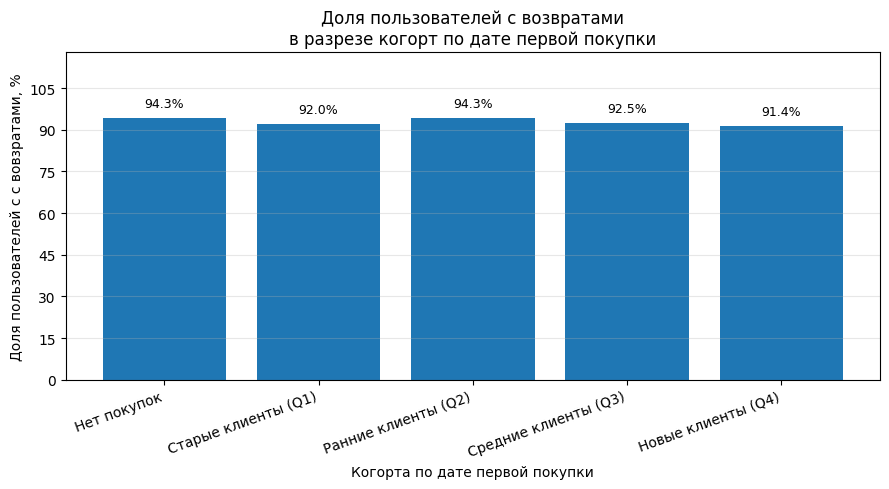


--- Сильные возвраты (target > 0.3) по когортам ---


,Когорта по дате первой покупки,Количество пользователей,Среднее значение target,"Доля пользователей с возвратами, %"
0,Нет покупок,12,2.49,1.23
1,Старые клиенты (Q1),87,1.66,1.42
2,Ранние клиенты (Q2),77,1.63,1.23
3,Средние клиенты (Q3),81,1.83,1.35
4,Новые клиенты (Q4),95,1.93,1.58


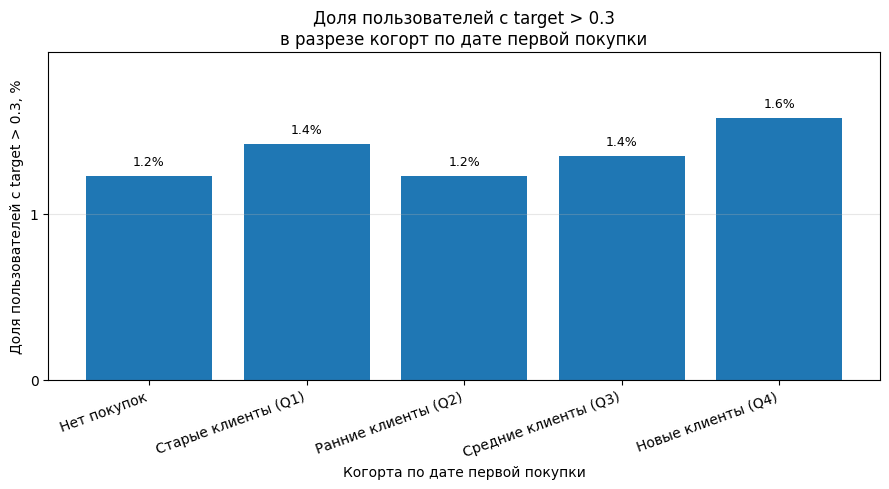

In [234]:
print("=== Гипотеза 5. Дата первой покупки и вероятность возврата в следующий месяц ===")

# Разбиваем исходный датасет на когорты по квантилям дат
df_h6 = df.copy()
df_h6["target"] = 0.3 - df_h6["target"]

q1 = df_h6["first_buy"].quantile(0.25)
q2 = df_h6["first_buy"].quantile(0.50)
q3 = df_h6["first_buy"].quantile(0.75)

print("\nГраницы квартилей по first_buy:")
print(f"Q1 (25%): {q1.date()}")
print(f"Q2 (50%): {q2.date()}")
print(f"Q3 (75%): {q3.date()}")

def first_buy_cohort(dt):
    if pd.isna(dt):
        return "Нет покупок"
    if dt <= q1:
        return "Старые клиенты (Q1)"
    if dt <= q2:
        return "Ранние клиенты (Q2)"
    if dt <= q3:
        return "Средние клиенты (Q3)"
    return "Новые клиенты (Q4)"

df_h6["first_buy_cohort"] = df_h6["first_buy"].map(first_buy_cohort)

cohort_order = [
    "Нет покупок",
    "Старые клиенты (Q1)",
    "Ранние клиенты (Q2)",
    "Средние клиенты (Q3)",
    "Новые клиенты (Q4)"
]

# Присваиваем бинарный признак: есть\нет возвраты в следующем месяце
df_h6["has_return_next"] = (df_h6["target"] > 0).astype(int)

# Выводим статистики по бинарному признаку
cohort_stats = (
    df_h6
    .groupby("first_buy_cohort", observed=False)
    .agg(
        users=("user_id", "count"),
        share_target_pos=("has_return_next", "mean"),
        mean_target=("target", "mean")
    )
    .reindex(cohort_order)
    .reset_index()
)

cohort_stats["share_target_pos"] = (cohort_stats["share_target_pos"] * 100).round(2)
cohort_stats["mean_target"] = cohort_stats["mean_target"].round(4)

cohort_stats_display = cohort_stats.rename(columns={
    "first_buy_cohort": "Когорта по дате первой покупки",
    "users": "Количество пользователей",
    "share_target_pos": "Доля пользователей с возвратами, %",
    "mean_target": "Среднее значение target"
})

print("\n--- Возвраты в ближайший месяц по когортам (first_buy) ---")
display(cohort_stats_display)

# Построение графика с долями пользователей с возвратами по возрастным когортам
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    cohort_stats_display["Когорта по дате первой покупки"],
    cohort_stats_display["Доля пользователей с возвратами, %"]
)

ax.set_title("Доля пользователей с возвратами\nв разрезе когорт по дате первой покупки")
ax.set_xlabel("Когорта по дате первой покупки")
ax.set_ylabel("Доля пользователей с с вовзратами, %")
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

max_share = cohort_stats_display["Доля пользователей с возвратами, %"].max()
ax.set_ylim(0, max_share * 1.25)

plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

for bar, val in zip(bars, cohort_stats_display["Доля пользователей с возвратами, %"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + max_share * 0.03,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

print("\n--- Сильные возвраты (target > 0.3) по когортам ---")
# Выделяем датафрейм для подгруппы с высокими возвратами
df_h6_high = df_h6[df_h6["target"] > 0.30].copy()

# Рассчитываем статистики для когорты с высокими возвратами
cohort_stats_high = (
    df_h6_high
    .groupby("first_buy_cohort", observed=False)
    .agg(
        users=("user_id", "count"),
        mean_target=("target", "mean")
    )
    .reindex(cohort_order)
    .reset_index()
)

total_users = df_h6.groupby("first_buy_cohort")["user_id"].count().reindex(cohort_order).values
cohort_stats_high["share_return"] = (cohort_stats_high["users"] / total_users * 100).round(2)
cohort_stats_high["mean_target"] = cohort_stats_high["mean_target"].round(4)

cohort_stats_high_display = cohort_stats_high.rename(columns={
    "first_buy_cohort": "Когорта по дате первой покупки",
    "users": "Количество пользователей",
    "share_return": "Доля пользователей с возвратами, %",
    "mean_target": "Среднее значение target"
})

display(cohort_stats_high_display)

# Построение графика распределения долей покупателей с высокими возвратами по возрастным когортам
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    cohort_stats_high["first_buy_cohort"],
    cohort_stats_high["share_return"]
)
ax.set_title("Доля пользователей с target > 0.3\nв разрезе когорт по дате первой покупки")
ax.set_xlabel("Когорта по дате первой покупки")
ax.set_ylabel("Доля пользователей с target > 0.3, %")
ax.grid(axis="y", alpha=0.3)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
max_share = cohort_stats_high["share_return"].max()
ax.set_ylim(0, max_share * 1.25)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
for bar, val in zip(bars, cohort_stats_high["share_return"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + max_share * 0.03,
        f"{val:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )
plt.tight_layout()
plt.show()

### Заключение по гипотезе 5:

1. **Общая доля пользователей с возвратами (`target > 0`)**  
   - Наибольшая доля возвратов у клиентов без покупок (94.35%) и ранних клиентов (Q2 — 94.27%).  
   - Наименьшая доля возвратов у новых клиентов (Q4 — 91.39%) и старых клиентов (Q1 — 92.01%).  
   - Среднее значение `target` колеблется между 0.294 и 0.31, что указывает на умеренные различия между когортами.

2. **Сильные возвраты (`target > 0.3`)**  
   - Абсолютное количество клиентов с сильными возвратами невелико (от 12 до 95 человек на когорту, доля от 1.23% до 1.58%).  
   - Наибольшая доля сильных возвратов у новых клиентов (Q4 — 1.58%).  
   - Среднее значение `target` среди этих пользователей самое высокое у новых клиентов (1.9268) и без покупок (2.4905 — небольшая группа, поэтому не интерпретируется для всей когорты).

3. **Тенденции по «возрасту» клиента**  
   - Различия по когортам умеренные.  
   - «Краевые» когорты (новые клиенты Q4 и старые клиенты Q1) демонстрируют немного более высокие средние значения `target` среди сильных возвратов.  
   - Клиенты среднего «возраста» (Q2 и Q3) выглядят относительно стабильными по показателю возвратов.

4. **Практическая интерпретация**  
   - Возраст клиента по дате первой покупки можно учитывать как дополнительный фактор сегментации:  
     - Новые и старые клиенты могут требовать отдельного подхода для снижения возвратов или стимулирования повторных покупок.  
   - Эффект умеренный; доля «сильных возвратов» крайне мала, поэтому влияние на общую стратегию ограничено.


# Гипотеза 6

**Идея гипотезы:**  
Изучим, как распределяются клиенты по историческому коэффициенту возвратов (`hist_return_rate`) в зависимости от «возраста» клиента, приближённо измеряемого через дату первой покупки (`first_buy`).  

- Есть ли различия по когортам: старые, средние, новые клиенты, а также клиенты без покупок?  
- Какие возрастные группы чаще попадают в бакеты с высокими историческими возвратами?  

**Стратегия проверки гипотезы:**

1. Рассчитываем исторический коэффициент возвратов:  
   - `hist_return_rate = total_return / total_buy` для клиентов с покупками и возвратами.  
   - Клиенты без покупок и с нулевыми возвратами формируют отдельные категории.

2. Формируем бакеты по историческим возвратам:  
   - «нет покупок», «0% возвратов», «0–10%», «10–50%», «50–100%», «100–500%», «>500%».

3. Для каждой когорты по `first_buy` строим распределение пользователей по бакетам исторических возвратов:  
   - Считаем количество пользователей в каждом бакете.  
   - Рассчитываем долю пользователей в процентах относительно когорты.

4. Визуализируем:  
   - Таблицу распределения по когорте и бакету исторических возвратов.  
   - Строим столбчатые диаграммы для наглядного сравнения когорт.


--- Описательные статистики hist_return_rate (там, где он посчитан) ---


,count,mean,std,min,25%,50%,75%,max
hist_return_rate,5399.00,13.71,525.72,0.00,0.36,0.66,1.57,38227.85



--- Распределение пользователей по корзинам исторических возвратов: ---


,Корзина по историческому коэффициенту возвратов,Количество пользователей
0,нет покупок,814
1,только возвраты,152
2,0% возвратов,19118
3,0–10%,170
4,10–50%,1885
5,50–100%,1365
6,100–500%,1466
7,>500%,361



--- Распределение пользователей по корзинам исторических возвратов и возрасту: ---


hist_return_bucket,нет покупок,только возвраты,0% возвратов,0–10%,10–50%,50–100%,100–500%,>500%
first_buy_cohort,,,,,,,,
Нет даты первой покупки,30,1,757,3,57,64,55,6
Старые клиенты (Q1),165,71,3970,55,730,514,477,129
Ранние клиенты (Q2),216,54,4613,52,439,323,432,118
Средние клиенты (Q3),188,16,4630,40,457,297,306,61
Новые клиенты (Q4),215,10,5148,20,202,167,196,47



--- Распределение пользователей по корзинам исторических возвратов и возрасту в процентах: ---


hist_return_bucket,Размер когорты,нет покупок,только возвраты,0% возвратов,0–10%,10–50%,50–100%,100–500%,>500%
first_buy_cohort,,,,,,,,,
Нет даты первой покупки,973,3.08%,0.10%,77.80%,0.31%,5.86%,6.58%,5.65%,0.62%
Старые клиенты (Q1),6111,2.70%,1.16%,64.96%,0.90%,11.95%,8.41%,7.81%,2.11%
Ранние клиенты (Q2),6247,3.46%,0.86%,73.84%,0.83%,7.03%,5.17%,6.92%,1.89%
Средние клиенты (Q3),5995,3.14%,0.27%,77.23%,0.67%,7.62%,4.95%,5.10%,1.02%
Новые клиенты (Q4),6005,3.58%,0.17%,85.73%,0.33%,3.36%,2.78%,3.26%,0.78%


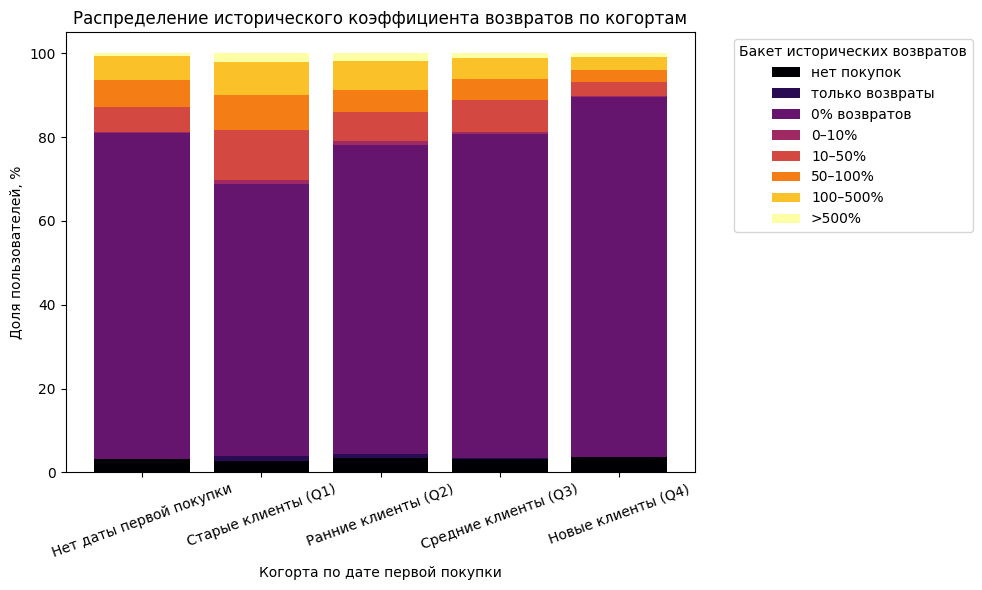

In [235]:
# Строим исторический коэффициент возвратов
df_h7 = df.copy()
mask_no_buy_no_ret  = (df_h7["total_buy"] == 0) & (df_h7["total_return"] == 0)
mask_no_buy_ret     = (df_h7["total_buy"] == 0) & (df_h7["total_return"] > 0)
mask_zero_ret    = (df_h7["total_buy"] > 0) & (df_h7["total_return"] == 0)
mask_nonzero_ret = (df_h7["total_buy"] > 0) & (df_h7["total_return"] > 0)

df_h7["hist_return_rate"] = np.nan
df_h7.loc[mask_nonzero_ret, "hist_return_rate"] = (
    df_h7.loc[mask_nonzero_ret, "total_return"] /
    df_h7.loc[mask_nonzero_ret, "total_buy"]
)
df_h7.loc[mask_no_buy_ret, "hist_return_rate"] = df_h7.loc[mask_no_buy_ret, "total_return"] 

print("\n--- Описательные статистики hist_return_rate (там, где он посчитан) ---")
display(df_h7["hist_return_rate"].describe().to_frame().T)

# Формируем корзины по историческим возвратам

# порядок корзин, который будем использовать везде
bucket_order = [
    "нет покупок",
    "только возвраты",
    "0% возвратов",
    "0–10%",
    "10–50%",
    "50–100%",
    "100–500%",
    ">500%"
]

df_h7["hist_return_bucket"] = None

df_h7.loc[mask_no_buy_no_ret,  "hist_return_bucket"] = "нет покупок"
df_h7.loc[mask_no_buy_ret,    "hist_return_bucket"] = "только возвраты"
df_h7.loc[mask_zero_ret, "hist_return_bucket"] = "0% возвратов"

bins   = [0, 0.1, 0.5, 1, 5, np.inf]
labels = ["0–10%", "10–50%", "50–100%", "100–500%", ">500%"]

bucket_series = pd.cut(
    df_h7.loc[mask_nonzero_ret, "hist_return_rate"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_h7.loc[mask_nonzero_ret, "hist_return_bucket"] = bucket_series

# Распределение пользователей по корзинам

print("\n--- Распределение пользователей по корзинам исторических возвратов: ---")

vc = (
    df_h7["hist_return_bucket"]
    .value_counts()
    .reindex(bucket_order)
    .rename_axis("Корзина по историческому коэффициенту возвратов")
    .reset_index(name="Количество пользователей")
)

display(vc)

# Добавляем когортный признак по возрасту клиента
q1 = df_h7["first_buy"].quantile(0.25)
q2 = df_h7["first_buy"].quantile(0.50)
q3 = df_h7["first_buy"].quantile(0.75)

def first_buy_cohort(dt):
    if pd.isna(dt):
        return "Нет даты первой покупки"
    if dt <= q1:
        return "Старые клиенты (Q1)"
    if dt <= q2:
        return "Ранние клиенты (Q2)"
    if dt <= q3:
        return "Средние клиенты (Q3)"
    return "Новые клиенты (Q4)"

df_h7["first_buy_cohort"] = df_h7["first_buy"].map(first_buy_cohort)
print("\n--- Распределение пользователей по корзинам исторических возвратов и возрасту: ---")
cohort_vs_hist_bucket = (
    df_h7
    .pivot_table(
        index="first_buy_cohort",
        columns="hist_return_bucket",
        values="user_id",
        aggfunc="count",
        fill_value=0
    )
    .reindex(index=[
        "Нет даты первой покупки",
        "Старые клиенты (Q1)",
        "Ранние клиенты (Q2)",
        "Средние клиенты (Q3)",
        "Новые клиенты (Q4)"
    ])
    .reindex(columns=bucket_order)
)

display(cohort_vs_hist_bucket)

# Перевод в доли внутри когорты
cohort_vs_hist_bucket_pct = cohort_vs_hist_bucket.div(cohort_vs_hist_bucket.sum(axis=1), axis=0) * 100

print("\n--- Распределение пользователей по корзинам исторических возвратов и возрасту в процентах: ---")
# Выводим таблицу с долями в процентах пользователей по корзинам исторических возвратов и возрасту
df_with_percents = cohort_vs_hist_bucket_pct.copy()
df_with_percents["Размер когорты"] = cohort_vs_hist_bucket.sum(axis=1)
cols = ["Размер когорты"] + bucket_order
df_with_percents = df_with_percents[cols]
def fmt(x):
    return f"{x:.2f}%"
for col in bucket_order:
    df_with_percents[col] = df_with_percents[col].apply(fmt)
display(df_with_percents)

# Построение stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(cohort_vs_hist_bucket_pct))
colors = plt.cm.inferno(np.linspace(0, 1, len(bucket_order)))

for idx, bucket in enumerate(bucket_order):
    values = cohort_vs_hist_bucket_pct[bucket].values
    ax.bar(
        cohort_vs_hist_bucket_pct.index,
        values,
        bottom=bottom,
        label=bucket,
        color=colors[idx]
    )
    bottom += values

ax.set_ylabel("Доля пользователей, %")
ax.set_xlabel("Когорта по дате первой покупки")
ax.set_title("Распределение исторического коэффициента возвратов по когортам")
ax.legend(title="Бакет исторических возвратов", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Вывод по гипотезе 6. Влияние исторического коэффициента возвратов на поведение клиентов

Наблюдаются различия в распределении исторического коэффициента возвратов между когортами по дате первой покупки.


Анализ распределения бакетов исторического коэффициента возвратов по когортам (разбивка по дате первой покупки) показывает ряд устойчивых и важных закономерностей:

### 1. Доля клиентов без возвратов растёт от старых когорт к новым
- **Старые клиенты (Q1):** 64.96% без возвратов  
- **Новые клиенты (Q4):** 85.73% без возвратов  

Новые клиенты выглядят более «здоровой» аудиторией по возвратам.

### 2. Старые клиенты чаще демонстрируют высокий уровень возвратов
Бакеты с высоким return rate (50–100%, 100–500%, >500%) особенно характерны для Q1:

- **Q1 → “100–500%”:** 7.81%  
- **Q1 → “>500%”:** 2.11%  
- В новых когорт таких клиентов заметно меньше: например, в Q4 → “>500%” всего 0.78%.

Это указывает на то, что именно старые клиенты создают наибольшую финансовую нагрузку: они чаще возвращают товар и при этом продолжают покупать.

### 3. Доля пользователей только с возвратами крайне мала
- В старых когортных группах: **1.16% → 0.27%** по мере перехода к Q3  
- В новых: всего **0.17%**

Такая группа действительно существует, но не является массовой.

### 4. “Нет покупок” распределены равномерно и дают 2.7–3.6%
Это пользователи, которые зарегистрировались, но так ничего и не купили.  
На них не влияют проблемы возвратов, но они важны при анализе качества трафика и воронки.

### 5. Основная зона риска — когорты Q1 и частично Q2
У этих клиентов заметно выше доля всех “плохих” бакетов:
- 10–50%
- 50–100%
- 100–500%
- \>500%

### 6. Новые клиенты имеют отличную обратную связь для прогноза LTV
Высокая доля «0% возвратов» + низкие доли плохих бакетов означают:
- минимальный возвратный риск,  
- высокая маржинальность,  
- меньше будущих возвратных расходов.

---

### Заключение
**Исторический уровень возвратов различается между когортами: старые клиенты дают больше проблемных возвратов, тогда как новые клиенты — наиболее качественная и прибыльная аудитория.**  

Это означает, что:
- при прогнозировании LTV когортность по дате первой покупки обязательна;  
- маркетинговые усилия стоит смещать в сторону сегментов с профилем возвратов, похожим на Q3–Q4;  
- с когорой Q1 нужно проработать отдельные гипотезы: перерасчёт условий, антифрод, ограничение частоты заказов, пересмотр ассортимента или коммуникаций.

In [236]:
print("=== Вывод средних и медианных исторических возвратов и покупок по возрастным когортам ===")

df_h7_1 = df_h7.copy()

cohort_order = [
    "Нет даты первой покупки",
    "Старые клиенты (Q1)",
    "Ранние клиенты (Q2)",
    "Средние клиенты (Q3)",
    "Новые клиенты (Q4)"
]

cohort_mean_stats = (
    df_h7_1
    .groupby("first_buy_cohort", observed=False)
    .agg(
        users=("user_id", "count"),
        mean_total_return=("total_return", "mean"),
        mean_total_buy=("total_buy", "mean")
    )
    .reindex(cohort_order)
    .reset_index()
)

cohort_mean_stats_display = cohort_mean_stats.rename(columns={
    "first_buy_cohort": "Когорта по дате первой покупки",
    "users": "Количество пользователей",
    "mean_total_return": "Среднее историческое значение возвратов",
    "mean_total_buy": "Среднее историческое значение покупок"
})

display(cohort_mean_stats_display)


cohort_median_stats = (
    df_h7_1
    .groupby("first_buy_cohort", observed=False)
    .agg(
        users=("user_id", "count"),
        median_total_return=("total_return", "median"),
        median_total_buy=("total_buy", "median")
    )
    .reindex(cohort_order)
    .reset_index()
)

cohort_median_stats_display = cohort_median_stats.rename(columns={
    "first_buy_cohort": "Когорта по дате первой покупки",
    "users": "Количество пользователей",
    "median_total_return": "Медианное историческое значение возвратов",
    "median_total_buy": "Медианное историческое значение покупок"
})

display(cohort_median_stats_display)

=== Вывод средних и медианных исторических возвратов и покупок по возрастным когортам ===


,Когорта по дате первой покупки,Количество пользователей,Среднее историческое значение возвратов,Среднее историческое значение покупок
0,Нет даты первой покупки,973,464.26,1077.00
1,Старые клиенты (Q1),6111,539.61,1261.78
2,Ранние клиенты (Q2),6247,347.69,926.15
3,Средние клиенты (Q3),5995,349.42,1089.40
4,Новые клиенты (Q4),6005,67.46,277.45


,Когорта по дате первой покупки,Количество пользователей,Медианное историческое значение возвратов,Медианное историческое значение покупок
0,Нет даты первой покупки,973,0.00,75.66
1,Старые клиенты (Q1),6111,0.00,75.03
2,Ранние клиенты (Q2),6247,0.00,48.05
3,Средние клиенты (Q3),5995,0.00,58.17
4,Новые клиенты (Q4),6005,0.00,38.66


### Статистические проверки гипотезы 6

**Гипотеза 6:**  
Вероятность возврата зависит от возраста клиента (когорты по дате первой покупки). Старые клиенты совершают больше возвратов в историческом разрезе, чем новые клиенты.  

**Цель анализа:**  
Определить, какая возрастная когорта является статистически более «проблемной» с точки зрения возвратов, используя **исторические бакеты возвратов** (например, 50–100%, 100–500% и т.д.).  

**Подход:**  

1. Разделяем пользователей на возрастные когорты по дате первой покупки:  
   - Нет даты первой покупки  
   - Старые клиенты (Q1)  
   - Ранние клиенты (Q2)  
   - Средние клиенты (Q3)  
   - Новые клиенты (Q4)  

2. Для каждой возрастной когорты считаем количество пользователей в каждом проблемном **бакете исторических возвратов**:  
   - 10–50%, 50–100%, 100–500%, >500%  

3. Т.к. в каждой группе значительное количество наблюдений, то согласно ЦПТ вероятность попасть\не попасть в проблемную категорию будет распределена нормально, поэтому для каждой «проблемной» категории (например, 50–100%, 100–500%) проводим **z-тест для долей** по каждой паре когорт, чтобы определить, какая из когорт статистически значимо отличается по доле проблемных пользователей.  

4. Для коррекции на множественные сравнения используем метод **Бонферрони**, чтобы контролировать вероятность ложноположительных результатов.

H<sub>0</sub>: Пользователи из возрастной группы A встречаются в выборке с выским историческим возвратом так же часто как пользователи из возрастной группы B.

H<sub>1</sub>: Пользователи из одной возрастной группы встречаются чаще, чем другие.

**Вывод:**  
Эксперимент позволяет сразу определить **направление различий** (в какой когортe больше пользователей с высокими историческими возвратами) и проверить их **статистическую значимость**.

=== Z-тест по частоте попадания возрастных групп в бакеты с повышенными историческими возвратами ===


,Корзина,Когорта 1,Когорта 2,Доля Когорта 1,Доля Когорта 2,p-value (скорректированное),Статистически значимо?,Чаще попадает в бакет
0,10–50%,Нет даты первой покупки,Старые клиенты (Q1),5.860000,11.950000,0.000000,Да,Старые клиенты (Q1)
1,10–50%,Нет даты первой покупки,Ранние клиенты (Q2),5.860000,7.030000,1.000000,Нет,Ранние клиенты (Q2)
2,10–50%,Нет даты первой покупки,Средние клиенты (Q3),5.860000,7.620000,0.507600,Нет,Средние клиенты (Q3)
3,10–50%,Нет даты первой покупки,Новые клиенты (Q4),5.860000,3.360000,0.001300,Да,Нет даты первой покупки
4,10–50%,Старые клиенты (Q1),Ранние клиенты (Q2),11.950000,7.030000,0.000000,Да,Старые клиенты (Q1)
5,10–50%,Старые клиенты (Q1),Средние клиенты (Q3),11.950000,7.620000,0.000000,Да,Старые клиенты (Q1)
6,10–50%,Старые клиенты (Q1),Новые клиенты (Q4),11.950000,3.360000,0.000000,Да,Старые клиенты (Q1)
7,10–50%,Ранние клиенты (Q2),Средние клиенты (Q3),7.030000,7.620000,1.000000,Нет,Средние клиенты (Q3)
8,10–50%,Ранние клиенты (Q2),Новые клиенты (Q4),7.030000,3.360000,0.000000,Да,Ранние клиенты (Q2)
9,10–50%,Средние клиенты (Q3),Новые клиенты (Q4),7.620000,3.360000,0.000000,Да,Средние клиенты (Q3)


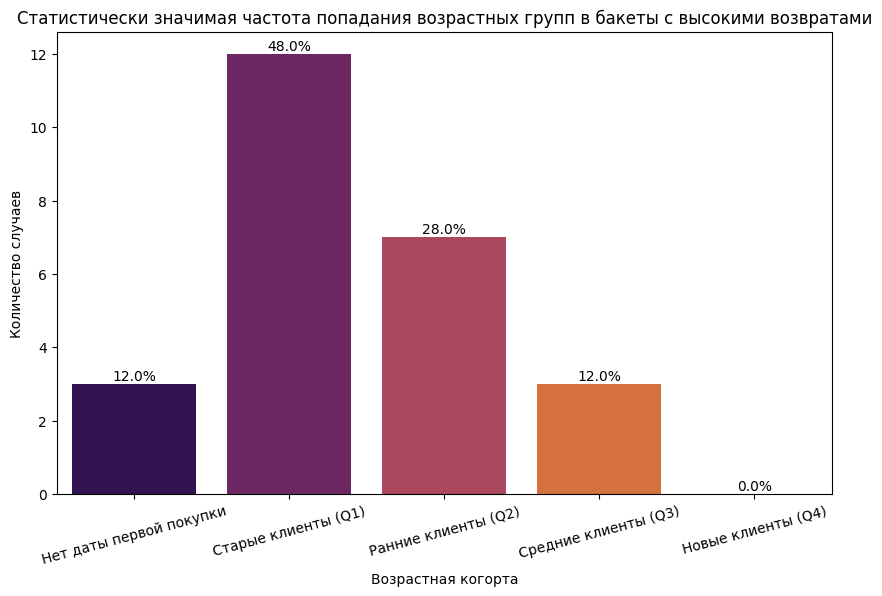

In [237]:
print("=== Z-тест по частоте попадания возрастных групп в бакеты с повышенными историческими возвратами ===")

df_z_test = df_h7.copy()

bucket_order = [
    "10–50%",
    "50–100%",
    "100–500%",
    ">500%"
]

cohort_order = [
    "Нет даты первой покупки",
    "Старые клиенты (Q1)",
    "Ранние клиенты (Q2)",
    "Средние клиенты (Q3)",
    "Новые клиенты (Q4)"
]

results = []

# Для каждой корзины возвратов по всем комбинациям возрастных пар проводим z-test
for bucket in bucket_order:
    df_z_test[f'in_bucket_{bucket}'] = (df_z_test['hist_return_bucket'] == bucket).astype(int)
    pairs = list(itertools.combinations(cohort_order, 2))
    p_values = []
    pair_list = []
    counts_dict = {}
    
    for c1, c2 in pairs:
        subset = df_z_test[df_z_test['first_buy_cohort'].isin([c1, c2])]
        counts = subset.groupby('first_buy_cohort')[f'in_bucket_{bucket}'].sum()
        nobs = subset.groupby('first_buy_cohort')[f'in_bucket_{bucket}'].count()
        
        proportion_c1 = counts[c1] / nobs[c1]
        proportion_c2 = counts[c2] / nobs[c2]
        counts_dict[(c1, c2)] = (proportion_c1, proportion_c2)
        
        stat, pval = proportions_ztest(counts.values, nobs.values)
        p_values.append(pval)
        pair_list.append((c1, c2))
    # Добавляем поправку Бонферони для множественных сравнений
    reject, pvals_corrected, _, _ = multipletests(p_values, method='bonferroni')
    #Выделяем возрастную когорту, которая чаще попадает в корзину
    for (c1, c2), p_corr, r in zip(pair_list, pvals_corrected, reject):
        prop1, prop2 = counts_dict[(c1, c2)]
        if prop1 > prop2:
            more_freq = c1
        elif prop2 > prop1:
            more_freq = c2
        else:
            more_freq = "равны"
        
        results.append({
            'Корзина': bucket,
            'Когорта 1': c1,
            'Когорта 2': c2,
            'Доля Когорта 1': round(prop1*100, 2),
            'Доля Когорта 2': round(prop2*100, 2),
            'p-value (скорректированное)': round(p_corr, 4),
            'Статистически значимо?': 'Да' if r else 'Нет',
            'Чаще попадает в бакет': more_freq
        })

results_df = pd.DataFrame(results)
# Настраиваем датафрейм для вывода всех строк, окрашиваем значимые
pd.set_option('display.max_rows', None)
def highlight_significant(row):
    if row["Статистически значимо?"] == "Да":
        return ["background-color: #D9EDF7"] * len(row)  # голубой
    else:
        return [""] * len(row)

styled_df = results_df.style.apply(highlight_significant, axis=1)
display(styled_df)

# Строим график распределения когорт по статистически значимым попаданиям в проблемную корзину возвратов
sig_df = results_df[results_df["Статистически значимо?"] == "Да"]
freq_df = sig_df['Чаще попадает в бакет'].value_counts().reindex(cohort_order, fill_value=0)
freq_df = freq_df.reset_index()
freq_df.columns = ['Когорта', 'Частота']

total = freq_df['Частота'].sum()
freq_df['Процент'] = freq_df['Частота'] / total * 100

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x='Когорта',
    y='Частота',
    hue='Когорта',
    data=freq_df,
    palette='inferno',
    legend=False)

for i, row in freq_df.iterrows():
    ax.text(i, row['Частота'] + 0.1, f"{row['Процент']:.1f}%", ha='center')

ax.set_title('Статистически значимая частота попадания возрастных групп в бакеты с высокими возвратами')
ax.set_ylabel('Количество случаев')
ax.set_xlabel('Возрастная когорта')
plt.xticks(rotation=15)
plt.show()

## Заключение по статистическим проверкам гипотезы 6
- Наиболее проблемная когорта с точки зрения возвратов — **старые клиенты (Q1)**.  
- Ранние клиенты (Q2) и средние клиенты (Q3) занимают промежуточное положение.  
- Новые клиенты (Q4) практически не попадают в высокие бакеты возвратов.  
- Гипотеза о том, что доля пользователей с высокими историческими возвратами различается между когортами, **подтверждается**, и направление различий указано в колонке «Чаще попадает в бакет».


# Гипотеза 7
- Клиенты, которые не сразу начали покупать, совершают меньше покупок
- Клиенты, которые не сразу начали покупать, совершают больше возвратов
## Проверка гипотезы
1. Обработаем пропуски в `first_login`, `reg_dt`, `first_buy`

    1.1 Если не указана одна из `first_login` или `reg_dt`, то присваиваем известное значение даты в неизвестную.
    
    1.2 Если не указаны обе - `first_login`, `reg_dt`, считаем, что пропуск в дате означает, что дата меньше среза, тогда установим в пропусках `min(date) - days(1)`

    1.2 Если `first_buy` не указан, но при этом `total_buy` или `total_return` не нулевые, то тогда устанавливаем `first_buy` как `min(date) - days(1)`
2. Обработка аномалий дат `first_login`, `reg_dt`, `first_buy`

    2.2 Из двух дат `first_login` и `reg_dt` для оценки задержки берём ту, что меньше `first_buy`

    2.3 Если обе даты меньше `first_buy`, то выделяем в отдельную группу - исследование невозможно
3. Вычислим `delay_in_days` для каждой строчки df
4. Разобьём на когорты по значению `delay_in_days`: big_delay, normal_delay, no_delay
5. Посмотрим значения `target` и `history_return_ratio` в этих когортах
6. Проведём стат тест значимости различий в распределении при необходимости

=== Обработка пропусков в столбцах с датами ===


,first_login,reg_dt,first_buy
count,25331,25327,24358
mean,2025-03-13 23:15:02.025186816,2024-12-06 08:07:56.455955712,2025-03-11 14:14:29.628048384
min,2024-09-21 00:00:00,2022-10-11 00:00:00,2023-08-08 00:00:00
25%,2025-02-07 00:00:00,2024-10-12 00:00:00,2025-02-10 00:00:00
50%,2025-03-23 00:00:00,2025-02-17 00:00:00,2025-03-25 00:00:00
75%,2025-04-25 00:00:00,2025-04-18 00:00:00,2025-05-01 00:00:00
max,2025-07-26 00:00:00,2025-07-26 00:00:00,2025-07-25 00:00:00



Количество не указанных дат первого логина: 0
Количество не указанных дат регистрации: 4
Количество не указанных дат первой покупки: 973

=== Заполним пропуски в датах ===

Количество не указанных дат регистрации: 0
Количество не указанных дат первой покупки: 0

=== Вычислим задержку между регистрацией и покупками в днях ===

Количество строк в группе, которую невозможно проанализировать из-за аномалий в датах: 6538
Количество аномалий в процентах от выборки: 25.81%

=== Описание столбца с задержкой между регистрацией и покупками в днях ===


count   18793.00
mean      122.67
std       214.23
min         1.00
25%         5.00
50%        13.00
75%       135.00
max       999.00
Name: delay_days, dtype: float64


Границы квартилей по delay_days:
Q1 (25%): 5.0
Q2 (50%): 13.0
Q3 (75%): 135.0


...

,Когорта по задержке до даты первой покупки,Количество пользователей,Медианное историческое значение возвратов,Медианное историческое значение покупок
0,Невозможно исследовать,6538,0.00,47.37
1,Очень быстрая покупка (Q1),4982,0.00,45.15
2,Быстрая покупка (Q2),4765,0.00,42.84
3,Медленная покупка (Q3),4356,0.00,42.93
4,Очень медленная покупка (Q4),4690,0.00,140.84



--- Распределение пользователей по корзинам исторических возвратов и задержке в днях до первой покупки: ---


hist_return_bucket,нет покупок,только возвраты,0% возвратов,0–10%,10–50%,50–100%,100–500%,>500%
delay_days_cohort,,,,,,,,
Невозможно исследовать,210,47,4975,35,448,346,384,93
Очень быстрая покупка (Q1),145,30,3887,23,319,235,254,89
Быстрая покупка (Q2),174,44,3629,19,331,207,296,65
Медленная покупка (Q3),161,27,3398,18,250,202,225,75
Очень медленная покупка (Q4),124,4,3229,75,537,375,307,39



--- Распределение пользователей по корзинам исторических возвратов и задержке в днях до первой покупки в процентах: ---


hist_return_bucket,Размер когорты,нет покупок,только возвраты,0% возвратов,0–10%,10–50%,50–100%,100–500%,>500%
delay_days_cohort,,,,,,,,,
Невозможно исследовать,6538,3.21%,0.72%,76.09%,0.54%,6.85%,5.29%,5.87%,1.42%
Очень быстрая покупка (Q1),4982,2.91%,0.60%,78.02%,0.46%,6.40%,4.72%,5.10%,1.79%
Быстрая покупка (Q2),4765,3.65%,0.92%,76.16%,0.40%,6.95%,4.34%,6.21%,1.36%
Медленная покупка (Q3),4356,3.70%,0.62%,78.01%,0.41%,5.74%,4.64%,5.17%,1.72%
Очень медленная покупка (Q4),4690,2.64%,0.09%,68.85%,1.60%,11.45%,8.00%,6.55%,0.83%


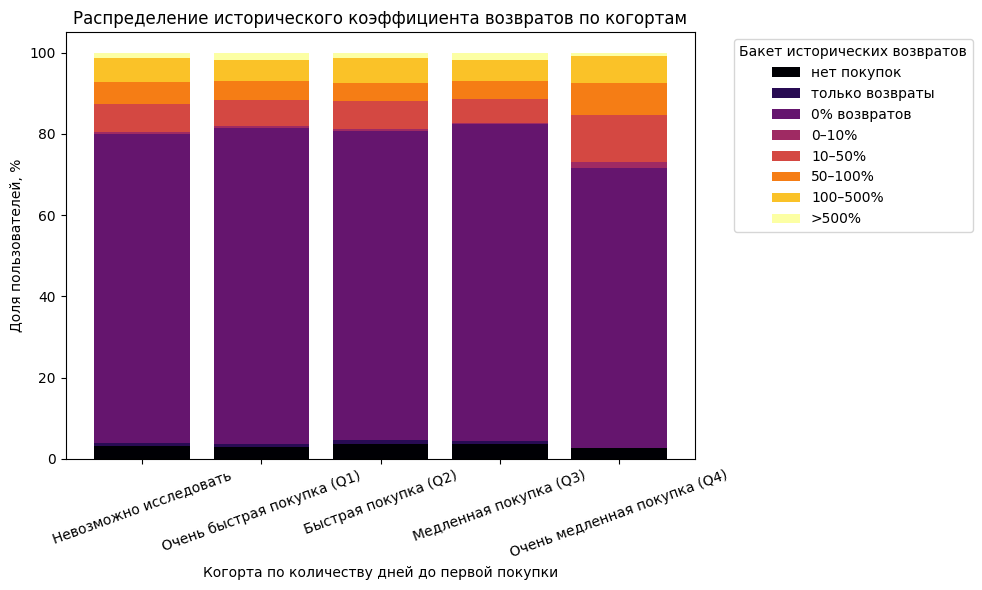

In [238]:
print("=== Обработка пропусков в столбцах с датами ===")
# Обработка пропусков в датах
df_h8 = df.copy()
display(df_h8[["first_login", "reg_dt", "first_buy"]].describe(datetime_is_numeric=True))
print(
    f"\nКоличество не указанных дат первого логина: {df_h8['first_login'].isna().sum()}"
    f"\nКоличество не указанных дат регистрации: {df_h8['reg_dt'].isna().sum()}"
    f"\nКоличество не указанных дат первой покупки: {df_h8['first_buy'].isna().sum()}"
)
print("\n=== Заполним пропуски в датах ===")
df_h8["reg_dt"] = df_h8["reg_dt"].fillna(df_h8["first_login"])
min_first_buy_date = df_h8["first_buy"].min() - pd.Timedelta(days=1)
df_h8["first_buy"] = df_h8["first_buy"].fillna(min_first_buy_date)
print(
    f"\nКоличество не указанных дат регистрации: {df_h8['reg_dt'].isna().sum()}"
    f"\nКоличество не указанных дат первой покупки: {df_h8['first_buy'].isna().sum()}"
)
print("\n=== Вычислим задержку между регистрацией и покупками в днях ===")
# Расчёт задержки между регистрацией и первой покупкой, обработка аномалий в данных
def calculate_days_delay(row):
    reg_dt = row["reg_dt"]
    first_login = row["first_login"]
    first_buy = row["first_buy"]
    if reg_dt < first_buy:
        return (first_buy - reg_dt).components.days
    elif first_login < first_buy:
        return (first_buy - first_login).components.days
    else:
        return np.nan
df_h8["delay_days"] = df_h8.apply(calculate_days_delay, axis = 1)
print(
    f"\nКоличество строк в группе, которую невозможно проанализировать из-за аномалий в датах: {df_h8['delay_days'].isna().sum()}"
    f"\nКоличество аномалий в процентах от выборки: {df_h8['delay_days'].isna().sum() / len(df_h8) * 100:.2f}%"
    )
print("\n=== Описание столбца с задержкой между регистрацией и покупками в днях ===")
# Выделение когорт по задержкам
display(df_h8["delay_days"][~df_h8["delay_days"].isna()].describe(datetime_is_numeric=True))

q1 = df_h8["delay_days"].quantile(0.25)
q2 = df_h8["delay_days"].quantile(0.50)
q3 = df_h8["delay_days"].quantile(0.75)

print("\nГраницы квартилей по delay_days:")
print(f"Q1 (25%): {q1}")
print(f"Q2 (50%): {q2}")
print(f"Q3 (75%): {q3}")


def delay_days_cohort(dt):
    if pd.isna(dt):
        return "Невозможно исследовать"
    if dt <= q1:
        return "Очень быстрая покупка (Q1)"
    if dt <= q2:
        return "Быстрая покупка (Q2)"
    if dt <= q3:
        return "Медленная покупка (Q3)"
    return "Очень медленная покупка (Q4)"

df_h8["delay_days_cohort"] = df_h8["delay_days"].map(delay_days_cohort)

cohort_order = [
    "Невозможно исследовать",
    "Очень быстрая покупка (Q1)",
    "Быстрая покупка (Q2)",
    "Медленная покупка (Q3)",
    "Очень медленная покупка (Q4)"
]

# Расчёт статистик по когортам задержек
cohort_mean_stats = (
    df_h8
    .groupby("delay_days_cohort", observed=False)
    .agg(
        users=("user_id", "count"),
        mean_total_return=("total_return", "mean"),
        mean_total_buy=("total_buy", "mean")
    )
    .reindex(cohort_order)
    .reset_index()
)

cohort_mean_stats_display = cohort_mean_stats.rename(columns={
    "delay_days_cohort": "Когорта задержке до даты первой покупки",
    "users": "Количество пользователей",
    "mean_total_return": "Среднее историческое значение возвратов",
    "mean_total_buy": "Среднее историческое значение покупок"
})

display(cohort_mean_stats_display)


cohort_median_stats = (
    df_h8
    .groupby("delay_days_cohort", observed=False)
    .agg(
        users=("user_id", "count"),
        median_total_return=("total_return", "median"),
        median_total_buy=("total_buy", "median")
    )
    .reindex(cohort_order)
    .reset_index()
)

cohort_median_stats_display = cohort_median_stats.rename(columns={
    "delay_days_cohort": "Когорта по задержке до даты первой покупки",
    "users": "Количество пользователей",
    "median_total_return": "Медианное историческое значение возвратов",
    "median_total_buy": "Медианное историческое значение покупок"
})

display(cohort_median_stats_display)

# Добавляем когорты по историческим возвратам
mask_no_buy_no_ret  = (df_h8["total_buy"] == 0) & (df_h8["total_return"] == 0)
mask_no_buy_ret     = (df_h8["total_buy"] == 0) & (df_h8["total_return"] > 0)
mask_zero_ret    = (df_h8["total_buy"] > 0) & (df_h8["total_return"] == 0)
mask_nonzero_ret = (df_h8["total_buy"] > 0) & (df_h8["total_return"] > 0)

df_h8["hist_return_rate"] = np.nan
df_h8.loc[mask_nonzero_ret, "hist_return_rate"] = (
    df_h8.loc[mask_nonzero_ret, "total_return"] /
    df_h8.loc[mask_nonzero_ret, "total_buy"]
)
df_h8.loc[mask_no_buy_ret, "hist_return_rate"] = df_h8.loc[mask_no_buy_ret, "total_return"] 
# порядок корзин, который будем использовать везде
bucket_order = [
    "нет покупок",
    "только возвраты",
    "0% возвратов",
    "0–10%",
    "10–50%",
    "50–100%",
    "100–500%",
    ">500%"
]

df_h8["hist_return_bucket"] = None

df_h8.loc[mask_no_buy_no_ret,  "hist_return_bucket"] = "нет покупок"
df_h8.loc[mask_no_buy_ret,    "hist_return_bucket"] = "только возвраты"
df_h8.loc[mask_zero_ret, "hist_return_bucket"] = "0% возвратов"

bins   = [0, 0.1, 0.5, 1, 5, np.inf]
labels = ["0–10%", "10–50%", "50–100%", "100–500%", ">500%"]

bucket_series = pd.cut(
    df_h8.loc[mask_nonzero_ret, "hist_return_rate"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_h8.loc[mask_nonzero_ret, "hist_return_bucket"] = bucket_series

print("\n--- Распределение пользователей по корзинам исторических возвратов и задержке в днях до первой покупки: ---")
# Строим распределение пользователей из когорт задержек по корзинам возратов
cohort_vs_hist_bucket = (
    df_h8
    .pivot_table(
        index="delay_days_cohort",
        columns="hist_return_bucket",
        values="user_id",
        aggfunc="count",
        fill_value=0
    )
    .reindex(index=[
        "Невозможно исследовать",
        "Очень быстрая покупка (Q1)",
        "Быстрая покупка (Q2)",
        "Медленная покупка (Q3)",
        "Очень медленная покупка (Q4)"
    ])
    .reindex(columns=bucket_order)
)

display(cohort_vs_hist_bucket)

# Перевод в доли внутри когорты
cohort_vs_hist_bucket_pct = cohort_vs_hist_bucket.div(cohort_vs_hist_bucket.sum(axis=1), axis=0) * 100

print("\n--- Распределение пользователей по корзинам исторических возвратов и задержке в днях до первой покупки в процентах: ---")
df_with_percents = cohort_vs_hist_bucket_pct.copy()
df_with_percents["Размер когорты"] = cohort_vs_hist_bucket.sum(axis=1)
cols = ["Размер когорты"] + bucket_order
df_with_percents = df_with_percents[cols]
def fmt(x):
    return f"{x:.2f}%"
for col in bucket_order:
    df_with_percents[col] = df_with_percents[col].apply(fmt)
display(df_with_percents)

# Построение stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(cohort_vs_hist_bucket_pct))
colors = plt.cm.inferno(np.linspace(0, 1, len(bucket_order)))

for idx, bucket in enumerate(bucket_order):
    values = cohort_vs_hist_bucket_pct[bucket].values
    ax.bar(
        cohort_vs_hist_bucket_pct.index,
        values,
        bottom=bottom,
        label=bucket,
        color=colors[idx]
    )
    bottom += values

ax.set_ylabel("Доля пользователей, %")
ax.set_xlabel("Когорта по количеству дней до первой покупки")
ax.set_title("Распределение исторического коэффициента возвратов по когортам")
ax.legend(title="Бакет исторических возвратов", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Выводы по распределению исторических возвратов в зависимости от задержки до первой покупки

#### 1. Поведение пользователей в когортax Q1–Q3 практически одинаково
Когорты  
*«Очень быстрая покупка (Q1)»*,  
*«Быстрая покупка (Q2)»*,  
*«Медленная покупка (Q3)»*  
демонстрируют близкую структуру возвратов:
- 75–78% пользователей имеют **0% возвратов**.
- 5–7% пользователей попадают в корзину **10–50% возвратов**.
- 4–5% — в корзину **50–100% возвратов**.
- 5–6% — в корзину **100–500% возвратов**.
- 1–1.7% — в корзину **>500% возвратов**.

Это означает, что пользователи, совершающие покупку в течение разумного времени после регистрации, имеют **стабильное и похожее паттерновое поведение**.

#### 2. Когорта «Очень медленная покупка (Q4)» заметно отличается
Для пользователей, у которых задержка между регистрацией и первой покупкой максимальная, наблюдается существенное изменение структуры возвратов:
- **0% возвратов** — только **68.85%** (ниже других когорт).
- Значительно выше доля проблемных корзин:
  - **10–50%** — 11.45%.
  - **50–100%** — 8.00%.
  - **100–500%** — 6.55%.

Таким образом, слишком длительная задержка до первой покупки **ассоциирована с повышенным риском возвратов** и более нестабильным поведением.

#### 3. Когорта «Невозможно исследовать» похожа на Q1–Q3
Несмотря на аномалии в датах, структура возвратов у этой когорты сопоставима с Q1–Q3. Это указывает на то, что проблемы с датами, вероятно, носят технический характер и **не отражают отличий в поведении**.

#### 4. Эффект не линейный: ухудшение поведения наблюдается только в Q4
Между Q1, Q2 и Q3 различия минимальны.  
Резкое ухудшение поведения фиксируется **только в когорте Q4**, что говорит о существовании порогового значения задержки.

#### 5. Интерпретация
- Q1–Q3 — это **нормальные и предсказуемые пользователи**.
- Q4 — это **потенциально сложная группа**, характеризующаяся:
  - задержкой принятия решения о первой покупке,
  - повышенной вероятностью неудовлетворенности,
  - более высоким уровнем возвратов.

#### 6. Рекомендации
- Провести углублённое исследование пользователей когорты Q4 (источники трафика, товары первой покупки, взаимодействие с платформой).
- Использовать задержку до первой покупки как **признак риска повышенной возвратности**.
- Проверить пересечение когорт задержки с возрастными группами для выявления дополнительных закономерностей.


# Статистические проверки гипотезы 7

**Гипотеза 7:**  
Вероятность возврата зависит от разницы в днях между датой регистрации и датой первой покупки. Клиенты, которые долго ничего не покупают совершают больше возвратов в историческом разрезе, чем клиенты, которые сразу начали покупать.  

**Цель анализа:**  
Определить, какая когорта по задержкам является статистически более «проблемной» с точки зрения возвратов, используя **исторические бакеты возвратов** (например, 50–100%, 100–500% и т.д.).  

**Подход:**  

1. Разделяем пользователей на когорты по количеству дней задержки между датой регистрации и датой первой покупки:  
   - Невозможно исследовать  
   - Очень быстрая покупка (Q1)  
   - Быстрая покупка (Q2)  
   - Медленная покупка (Q3)  
   - Очень медленная покупка (Q4)  

2. Для каждой когорты считаем количество пользователей в каждом проблемном **бакете исторических возвратов**:  
   - 10–50%, 50–100%, 100–500%, >500%  

3. Т.к. в каждой группе значительное количество наблюдений, то согласно ЦПТ вероятность попасть\не попасть в проблемную категорию будет распределена нормально, поэтому для каждой «проблемной» категории (например, 50–100%, 100–500%) проводим **z-тест для долей** по каждой паре когорт, чтобы определить, какая из когорт статистически значимо отличается по доле проблемных пользователей.  

4. Для коррекции на множественные сравнения используем метод **Бонферрони**, чтобы контролировать вероятность ложноположительных результатов.

H<sub>0</sub>: Пользователи с разным поведением после регистрации встречаются одинаково часто в бакетах исторических возвратов.

H<sub>1</sub>: Пользователи с разным количеством дней между датой регистрации и первой покупкой встречаются в бакетах исторических возвратов с разной частотой.

**Вывод:**  
Эксперимент позволяет сразу определить **направление различий** (в какой когортe больше пользователей с высокими историческими возвратами) и проверить их **статистическую значимость**.

=== Z-тест по частоте попадания пользователей разбитых на группы по дате задержки до первой покупки в бакеты с повышенными историческими возвратами ===


,Корзина,Когорта 1,Когорта 2,Доля Когорта 1,Доля Когорта 2,p-value (скорректированное),Статистически значимо?,Чаще попадает в бакет
0,10–50%,Невозможно исследовать,Очень быстрая покупка (Q1),6.850000,6.400000,1.000000,Нет,Невозможно исследовать
1,10–50%,Невозможно исследовать,Быстрая покупка (Q2),6.850000,6.950000,1.000000,Нет,Быстрая покупка (Q2)
2,10–50%,Невозможно исследовать,Медленная покупка (Q3),6.850000,5.740000,0.201300,Нет,Невозможно исследовать
3,10–50%,Невозможно исследовать,Очень медленная покупка (Q4),6.850000,11.450000,0.000000,Да,Очень медленная покупка (Q4)
4,10–50%,Очень быстрая покупка (Q1),Быстрая покупка (Q2),6.400000,6.950000,1.000000,Нет,Быстрая покупка (Q2)
5,10–50%,Очень быстрая покупка (Q1),Медленная покупка (Q3),6.400000,5.740000,1.000000,Нет,Очень быстрая покупка (Q1)
6,10–50%,Очень быстрая покупка (Q1),Очень медленная покупка (Q4),6.400000,11.450000,0.000000,Да,Очень медленная покупка (Q4)
7,10–50%,Быстрая покупка (Q2),Медленная покупка (Q3),6.950000,5.740000,0.183600,Нет,Быстрая покупка (Q2)
8,10–50%,Быстрая покупка (Q2),Очень медленная покупка (Q4),6.950000,11.450000,0.000000,Да,Очень медленная покупка (Q4)
9,10–50%,Медленная покупка (Q3),Очень медленная покупка (Q4),5.740000,11.450000,0.000000,Да,Очень медленная покупка (Q4)


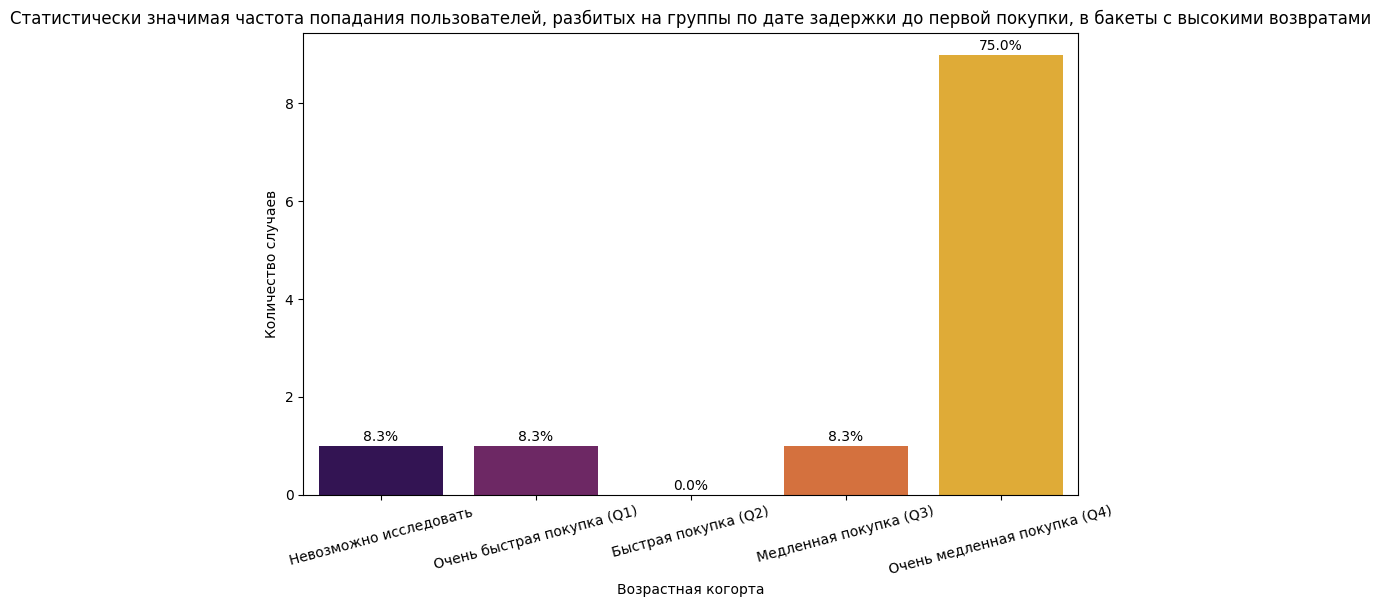

In [239]:
print("=== Z-тест по частоте попадания пользователей разбитых на группы по дате задержки до первой покупки в бакеты с повышенными историческими возвратами ===")

df_z_test_delay = df_h8.copy()

bucket_order = [
    "10–50%",
    "50–100%",
    "100–500%",
    ">500%"
]
cohort_order = [
    "Невозможно исследовать",
    "Очень быстрая покупка (Q1)",
    "Быстрая покупка (Q2)",
    "Медленная покупка (Q3)",
    "Очень медленная покупка (Q4)"
]
results = []

# Проводим z-test для всех проблемных корзин возвратов для каждой возможной пары когорт задержек
for bucket in bucket_order:
    df_z_test_delay[f'in_bucket_{bucket}'] = (df_z_test_delay['hist_return_bucket'] == bucket).astype(int)
    pairs = list(itertools.combinations(cohort_order, 2))
    p_values = []
    pair_list = []
    counts_dict = {}
    
    for c1, c2 in pairs:
        subset = df_z_test_delay[df_z_test_delay['delay_days_cohort'].isin([c1, c2])]
        counts = subset.groupby('delay_days_cohort')[f'in_bucket_{bucket}'].sum()
        nobs = subset.groupby('delay_days_cohort')[f'in_bucket_{bucket}'].count()
        
        proportion_c1 = counts[c1] / nobs[c1]
        proportion_c2 = counts[c2] / nobs[c2]
        counts_dict[(c1, c2)] = (proportion_c1, proportion_c2)
        
        stat, pval = proportions_ztest(counts.values, nobs.values)
        p_values.append(pval)
        pair_list.append((c1, c2))
    # Добавляем поправку, чтобы контролировать рост ошибок первого рода
    reject, pvals_corrected, _, _ = multipletests(p_values, method='bonferroni')
    # Определяем какая когорта попадает в бакет чаще
    for (c1, c2), p_corr, r in zip(pair_list, pvals_corrected, reject):
        prop1, prop2 = counts_dict[(c1, c2)]
        if prop1 > prop2:
            more_freq = c1
        elif prop2 > prop1:
            more_freq = c2
        else:
            more_freq = "равны"
        
        results.append({
            'Корзина': bucket,
            'Когорта 1': c1,
            'Когорта 2': c2,
            'Доля Когорта 1': round(prop1*100, 2),
            'Доля Когорта 2': round(prop2*100, 2),
            'p-value (скорректированное)': round(p_corr, 4),
            'Статистически значимо?': 'Да' if r else 'Нет',
            'Чаще попадает в бакет': more_freq
        })

results_df = pd.DataFrame(results)
pd.set_option('display.max_rows', None)
def highlight_significant(row):
    if row["Статистически значимо?"] == "Да":
        return ["background-color: #D9EDF7"] * len(row)
    else:
        return [""] * len(row)

styled_df = results_df.style.apply(highlight_significant, axis=1)
display(styled_df)

# Построение графика статистически значиных попаданий в проблемную корзину по когортам
sig_df = results_df[results_df["Статистически значимо?"] == "Да"]
freq_df = sig_df['Чаще попадает в бакет'].value_counts().reindex(cohort_order, fill_value=0)
freq_df = freq_df.reset_index()
freq_df.columns = ['Когорта', 'Частота']

total = freq_df['Частота'].sum()
freq_df['Процент'] = freq_df['Частота'] / total * 100

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x='Когорта',
    y='Частота',
    hue='Когорта',
    data=freq_df,
    palette='inferno',
    legend=False)

for i, row in freq_df.iterrows():
    ax.text(i, row['Частота'] + 0.1, f"{row['Процент']:.1f}%", ha='center')

ax.set_title('Статистически значимая частота попадания пользователей, разбитых на группы по дате задержки до первой покупки, в бакеты с высокими возвратами')
ax.set_ylabel('Количество случаев')
ax.set_xlabel('Возрастная когорта')
plt.xticks(rotation=15)
plt.show()

## Заключение по статистической проверке гипотезы 7
Когорта Q4 статистически чаще возвращает товары и является потенциально проблемной группой, что подтверждается z-тестом.